In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader,TensorDataset, Dataset
import scipy as sp
import torch.nn as nn
import torch.optim as optim
import time
from scipy.optimize import fsolve
import os
import torch.nn.functional as F
import datetime
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from scipy.optimize import differential_evolution
from statsmodels.tsa.ar_model import AutoReg

C:\Users\Nabang\anaconda3\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [3]:
public_holidays = np.load("Data/holidays.npy")

demand_price = np.load("Data/total_demand_price_data.npy",allow_pickle=True)
demand_volume = np.load("Data/total_demand_volume_data.npy",allow_pickle=True)

supply_price = np.load("Data/total_supply_price_data.npy",allow_pickle=True)
supply_volume = np.load("Data/total_supply_volume_data.npy",allow_pickle=True)


demand_price[2015] = demand_price[2015 - (24*7)]
demand_volume[2015] = demand_volume[2015 - (24*7)]

supply_price[2015] = supply_price[2015 - (24*7)]
supply_volume[2015] = supply_volume[2015 - (24*7)]

demand_price[10919] = demand_price[10919 - (24*7)]
demand_volume[10919] = demand_volume[10919 - (24*7)]

supply_price[10919] = supply_price[10919 - (24*7)]
supply_volume[10919] = supply_volume[10919 - (24*7)]

In [4]:
start_date = datetime.date(2018, 1, 1)
end_date = datetime.date(2019, 12, 31)

date_range = pd.date_range(start_date, end_date)


# Initialize empty vector
vector = []

# Iterate over each day from start to end date
current_date = start_date
while current_date <= end_date:
    # Check if the day is a weekend or Monday (weekday 0 represents Monday)
    if current_date.weekday() == 0 or current_date.weekday() >= 5:
        vector.append(1)  # Weekend or Monday
    else:
        vector.append(0)  # Not a weekend or Monday
    
    # Move to the next day
    current_date += datetime.timedelta(days=1)

# Convert the list to a numpy array if needed
vector = np.array(vector)

## Reconstruction Functions

In [5]:
def reconstruct(P, Q, K, curve):
    v = np.hstack((0,P,np.linspace(Q,K,len(curve))))
    p = np.hstack((3000,3000,curve))
    recon_curve = np.vstack((v,p))
    return recon_curve

def reconstruct_sup(P, Q, K, curve):
    v = np.hstack((np.linspace(P,Q,len(curve)),K, K + 200))
    p = np.hstack((curve,3000,3000))
    recon_curve = np.vstack((v,p))
    return recon_curve

## Figure 1

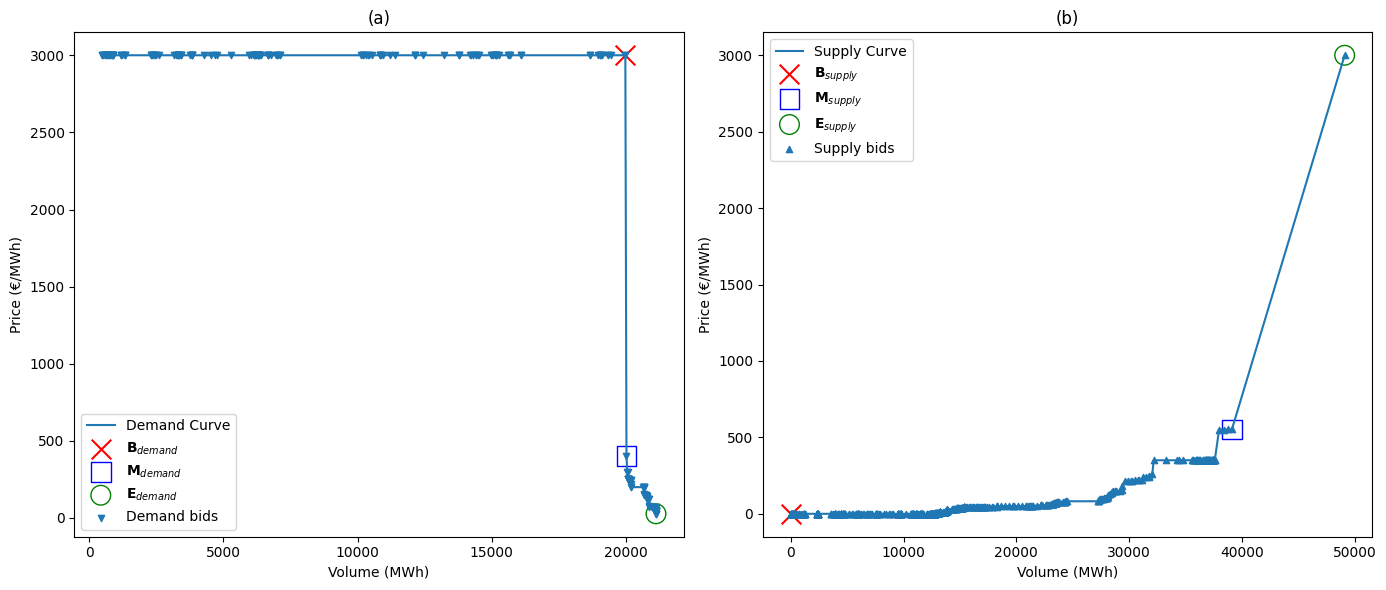

In [6]:
# Choose hour offset (8 AM)
h = 8

# Select demand price and volume for hour h across all days
demp = demand_price[np.arange(h, len(demand_price), 24)]
demv = demand_volume[np.arange(h, len(demand_price), 24)]

# Select supply price and volume for hour h across all days
supp = supply_price[np.arange(h, len(supply_price), 24)]
supv = supply_volume[np.arange(h, len(supply_price), 24)]

# Choose index i (day) to visualize
i = 1

# Create subplot with 2 plots side by side
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# B_demand: Last volume point where price is exactly 3000 €/MWh
P = demv[i][demp[i] == 3000][-1]

# M_demand: First point where price is less than 3000
Q_v = demv[i][demp[i] < 3000][0]
Q_p = demp[i][demp[i] < 3000][0]


# E_demand: Last point in the curve
K_v = demv[i][-1]
K_p = demp[i][-1]


# --- Plot Demand Curve ---
ax[0].plot(demv[i], demp[i], label="Demand Curve")
ax[0].scatter(P, 3000, label="$\mathbf{B}_{demand}$", color="red", s=200, marker="x")
ax[0].scatter(Q_v, Q_p, label="$\mathbf{M}_{demand}$", color="blue", s=200, marker="s", facecolor='none')
ax[0].scatter(K_v, K_p, label="$\mathbf{E}_{demand}$", color="green", s=200, marker="o", facecolor='none')
ax[0].scatter(demv[i], demp[i], label="Demand bids", color="tab:blue", s=20, marker="v")
ax[0].set_xlabel("Volume (MWh)")
ax[0].set_ylabel("Price (€/MWh)")
ax[0].set_title("(a)")
ax[0].legend()

# B_supply: First point in the curve (lowest volume)
P = supv[i][0]


# M_supply: Last point where price is less than 3000
Q_v = supv[i][supp[i] < 3000][-1]
Q_p = supp[i][supp[i] < 3000][-1]

# E_supply: First point where price is exactly 3000
K = supv[i][supp[i] == 3000][0]

# --- Plot Supply Curve ---
ax[1].plot(supv[i], supp[i], label="Supply Curve")
ax[1].scatter(P, 0, label="$\mathbf{B}_{supply}$", color="red", s=200, marker="x")
ax[1].scatter(Q_v, Q_p, label="$\mathbf{M}_{supply}$", color="blue", s=200, marker="s", facecolor='none')
ax[1].scatter(K, 3000, label="$\mathbf{E}_{supply}$", color="green", s=200, marker="o", facecolor='none')
ax[1].scatter(supv[i], supp[i], label="Supply bids", color="tab:blue", s=20, marker="^")
ax[1].set_xlabel("Volume (MWh)")
ax[1].set_ylabel("Price (€/MWh)")
ax[1].set_title("(b)")
ax[1].legend()

# Adjust layout and show plots
plt.tight_layout()
plt.show()


## Figure 4

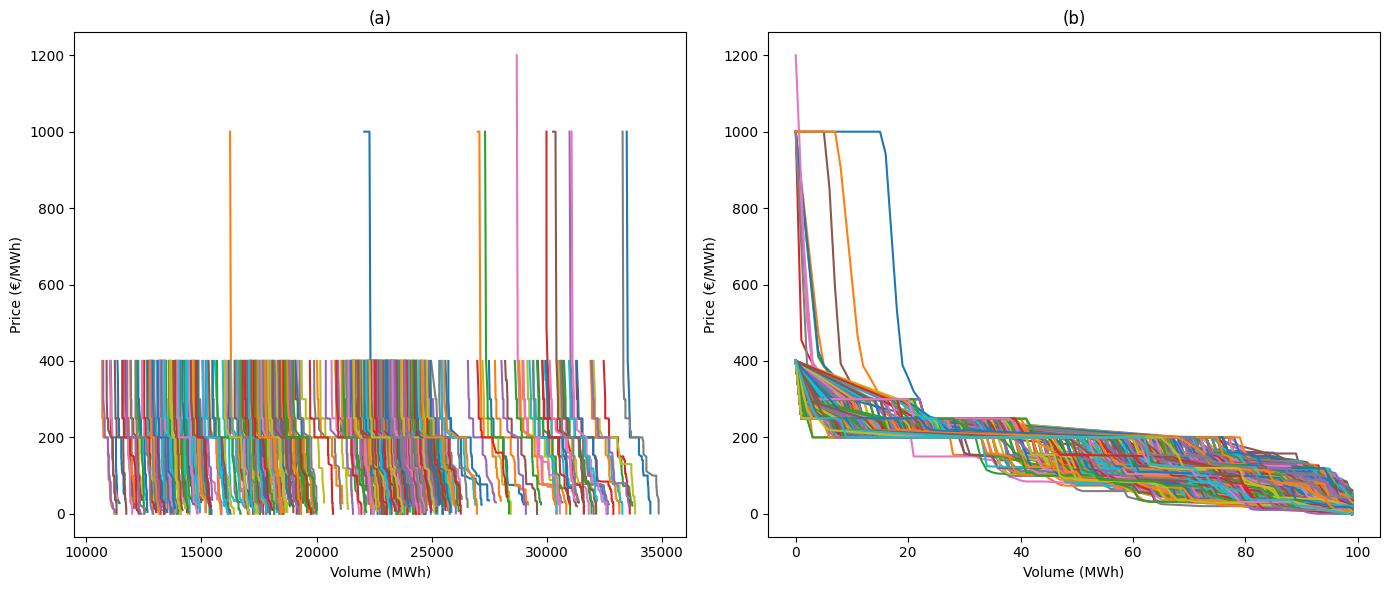

In [7]:
# Initialize an empty list to store interpolated price curves
c_p = []

# Loop over all daily demand curves
for i in range(len(demp)):
        # Select price values strictly below 3000 €/MWh for the i-th curve
        tp = (demp[i][demp[i] < 3000])

        # Select corresponding volume values for prices < 3000
        tv = (demv[i][demp[i] < 3000])

        # Create a uniform grid of 100 points between the min and max of tv
        grid = np.linspace(tv[0], tv[-1], num=100)

        # Interpolate prices onto the new grid and store
        c_p.append(np.interp(grid, tv, tp))

# Convert the list of interpolated curves to a NumPy array
c_p = np.array(c_p)

# Create a figure with 2 subplots side by side
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# --- (a) Plot raw demand curves below 3000 €/MWh ---
for i in range(len(demp)):
        ax[0].plot(demv[i][demp[i] < 3000], demp[i][demp[i] < 3000])
ax[0].set_xlabel("Volume (MWh)")
ax[0].set_ylabel("Price (€/MWh)")
ax[0].set_title("(a)")
# ax[0].legend()  # Disabled

# --- (b) Plot interpolated demand curves ---
for i in range(len(demp)):
    ax[1].plot(c_p[i])
ax[1].set_xlabel("Volume (MWh)")
ax[1].set_ylabel("Price (€/MWh)")
ax[1].set_title("(b)")
# ax[1].legend()  # Disabled

# Adjust subplot layout
plt.tight_layout()
plt.show()


## Figure 5

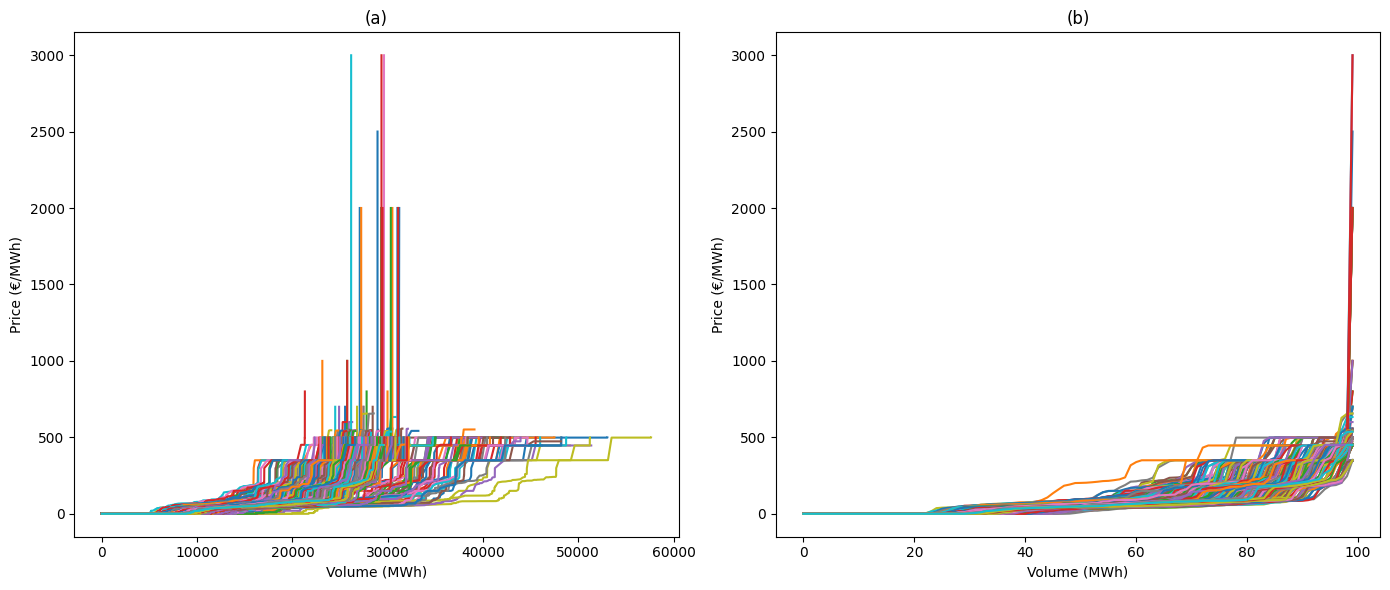

In [8]:
h = 8

supp = supply_price[np.arange(h, len(supply_price), 24)]
supv = supply_volume[np.arange(h, len(supply_price), 24)]

# Initialize an empty list to store interpolated price curves
c_p = []

    # Loop over all daily demand curves
for i in range(len(supp)):
    # Select price values strictly below 3000 €/MWh for the i-th curve
    tp = (supp[i][supp[i] < 3000])

    # Select corresponding volume values for prices < 3000
    tv = (supv[i][supp[i] < 3000])

    # Create a uniform grid of 100 points between the min and max of tv
    grid = np.linspace(tv[0], tv[-1], num=100)

    # Interpolate prices onto the new grid and store
    c_p.append(np.interp(grid, tv, tp))

# Convert the list of interpolated curves to a NumPy array
c_p = np.array(c_p)

# Create a figure with 2 subplots side by side
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# --- (a) Plot raw demand curves below 3000 €/MWh ---
for i in range(len(supp)):
    ax[0].plot(supv[i][supp[i] < 3000], supp[i][supp[i] < 3000])
ax[0].set_xlabel("Volume (MWh)")
ax[0].set_ylabel("Price (€/MWh)")
ax[0].set_title("(a)")

# --- (b) Plot interpolated demand curves ---
for i in range(len(supp)):
    ax[1].plot(c_p[i])
ax[1].set_xlabel("Volume (MWh)")
ax[1].set_ylabel("Price (€/MWh)")
ax[1].set_title("(b)")
    

# Adjust subplot layout
plt.tight_layout()
#plt.savefig("Fig_4_supply.png")
plt.show()

## Figure 6

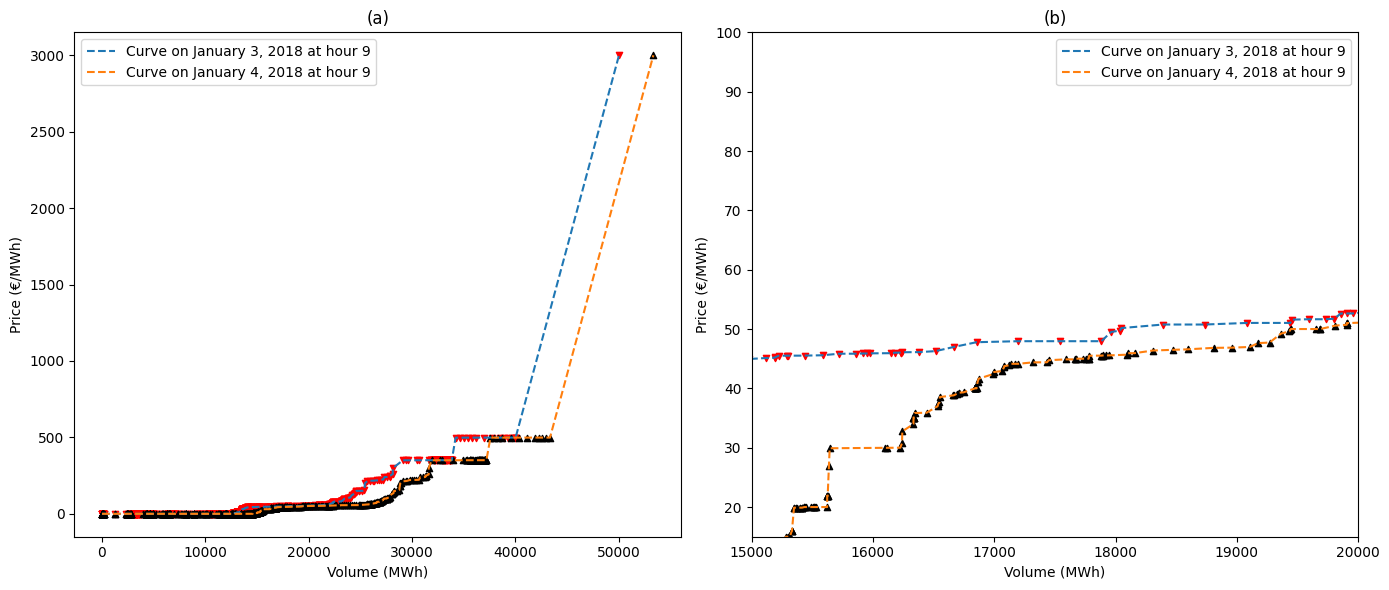

In [10]:
# Create a figure with 2 subplots side by side
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Select index i = 2 (i.e., third day)
i = 2

# --- Plot (a): Compare supply curves for two consecutive days ---

# Plot the supply curve for January 3, 2018 at hour 9
ax[0].plot(supv[i], supp[i], color="tab:blue", label="Curve on January 3, 2018 at hour 9", linestyle='--')

# Scatter the bid points on the same curve in red, using downward-pointing triangles
ax[0].scatter(supv[i], supp[i], color="red", s=20, marker="v")

# Plot the supply curve for January 4, 2018 at hour 9
ax[0].plot(supv[i+1], supp[i+1], color="tab:orange", label="Curve on January 4, 2018 at hour 9", linestyle='--')

# Scatter the bid points on the next day's curve in black, using upward-pointing triangles
ax[0].scatter(supv[i+1], supp[i+1], color="black", s=20, marker="^")

# Axis labels and title
ax[0].set_xlabel("Volume (MWh)")
ax[0].set_ylabel("Price (€/MWh)")
ax[0].set_title("(a)")
ax[0].legend()

# --- Plot (b): Same data but zoomed in to highlight volume/price ranges ---

ax[1].plot(supv[i], supp[i], color="tab:blue", label="Curve on January 3, 2018 at hour 9", linestyle='--')
ax[1].scatter(supv[i], supp[i], color="red", s=20, marker="v")
ax[1].plot(supv[i+1], supp[i+1], color="tab:orange", label="Curve on January 4, 2018 at hour 9", linestyle='--')
ax[1].scatter(supv[i+1], supp[i+1], color="black", s=20, marker="^")

# Axis labels and title
ax[1].set_xlabel("Volume (MWh)")
ax[1].set_ylabel("Price (€/MWh)")
ax[1].set_title("(b)")

# Zoom in to a specific volume and price range to highlight heterogeneity
ax[1].set_xlim([15000, 20000])
ax[1].set_ylim([15, 100])

ax[1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()


## Demand

### Linear Autoregression Function

In [21]:
def model_1(P):
    # Create lag-1 covariate (yesterday's values, shifted by 1 day)
    P_x = P[6:-1].reshape(len(P[6:-1]), 1)
    
    # Create lag-7 covariate (same day of previous week)
    P_x_7 = ((P[0:-7])).reshape(len(P[0:-7]), 1)  # this is correct

    # Create target variable (next day's value)
    P_y = P[7:].reshape(len(P[7:]), 1)  # this is correct

    # Extract public holiday indicator aligned with the target
    P_x_h = public_holidays[7:].reshape(len(P[7:]), 1)

    # Add a bias (intercept) column
    bias = np.ones((len(P_x), 1))

    # Combine covariates: lag-1, lag-7, holiday flag, and bias term
    P_covariate = np.hstack((P_x, P_x_7))
    P_covariate = np.hstack((P_covariate, P_x_h))
    P_covariate = np.hstack((P_covariate, bias))
    
    # Set the target
    P_target = P_y

    # Split data into training and testing (last 172 samples used for testing)
    x_train = P_covariate[:-172, :]
    x_test = P_covariate[-172:, :]

    # Further split training data into training and validation (69.6% for training)
    split = int(0.696 * len(x_train))
    x_valid = x_train[split:]
    x_train = x_train[:split]

    # Do the same split for the target values
    y_train = P_target[:-172, :]
    y_test = P_target[-172:, :]
    split = int(0.696 * len(y_train))
    y_valid = y_train[split:]
    y_train = y_train[:split]

    # Initialize search for best alpha (regularization strength) for Lasso
    mini = 99999999999
    min_alpha = 0
    for i in np.linspace(1, 200, 1000):
        lasso = Lasso(alpha=i)
        lasso.fit(x_train, y_train)
        y_pred = lasso.predict(x_valid)
        # Track the alpha that gives the lowest validation RMSE
        if np.sqrt(mean_squared_error(y_valid, y_pred)) < mini:
            mini = np.sqrt(mean_squared_error(y_valid, y_pred))
            min_alpha = i

    # Train final Lasso model on best alpha
    lasso = Lasso(alpha=min_alpha)
    lasso.fit(x_train, y_train)

    # Combine all predictions: train + validation + test (not returned)
    P_lr = np.hstack((lasso.predict(x_train), lasso.predict(x_valid)))
    P_lr = np.hstack((P_lr, lasso.predict(x_test)))

    # Final test prediction
    P_pred_lr = lasso.predict(x_test)

    # Return validation predictions, true test labels, and test predictions
    return lasso.predict(x_valid), y_test, P_pred_lr

## Training

In [34]:
def metric(x1, y1, x2, y2):
    # Generate a common grid to interpolate the two curves
    temp = np.sort(np.unique(np.union1d(x1,x2)))
    v = np.linspace(temp[0],temp[-1],10000)

    # Interpolate both curves on the common grid
    c1 = np.interp(v,x1,y1)
    c2 = np.interp(v,x2,y2)

    # Calculate RMSE between the interpolated curves
    area = np.sqrt(np.mean((c1 - c2)**2))

    return area


lr_predv_h = []
combined_predv_h_t2 = []

lr_predp_h = []
combined_predp_h_t2 = []

for h in range(24):
    # Extract price and volume for each hour
    demp = demand_price[np.arange(h,len(demand_price),24)]
    demv = demand_volume[np.arange(h,len(demand_price),24)]

    lr_predv = []
    combined_predv = []

    lr_predp = []
    combined_predp = []
    
    P = []
    Q = []
    K = []
    
    # Decompose each volume curve into 3 key points (P, Q, K)
    for i in range(len(demp)):
        P.append(demv[i][demp[i]==3000][-1])           # Point P: value at price = 3000
        Q.append(demv[i][demp[i]<3000][0])             # Point Q: first volume < 3000
        K.append(demv[i][-1])                          # Point K: last volume value
    
    P = np.array(P)
    Q = np.array(Q)
    K = np.array(K)
    
    #### LR data - Model predictions on decomposed components
    P_lr_val_train = model_1(P)[0][7:]    
    Q_lr_val_train = model_1(Q)[0][7:]
    K_lr_val_train = model_1(K)[0][7:]
    
    P_lr_val_test = model_1(P)[-1] 
    Q_lr_val_test = model_1(Q)[-1]
    K_lr_val_test = model_1(K)[-1]
    
    
    ### Smarter Naive predictions
    split = 7
    testv = demv[split:]
    testp = demp[split:]
    j = split
    
    sm_P = []
    sm_Q = []
    sm_K = []
    
    sm_predv = []
    sm_predp = []
    
    # Generate naive forecasts using either lag-1 or lag-7 depending on the vector
    for i in range(len(testv)):
        if vector[i+split] == 0:
            sm_P.append(demv[j - 1][demp[j - 1]==3000][-1])
            sm_Q.append(demv[j - 1][demp[j - 1]<3000][0])
            sm_K.append(demv[j - 1][-1])
            sm_predv.append(demv[j - 1])
            sm_predp.append(demp[j - 1])
        else:
            sm_P.append(demv[j - 7][demp[j - 7]==3000][-1])
            sm_Q.append(demv[j - 7][demp[j - 7]<3000][0])
            sm_K.append(demv[j - 7][-1])
            sm_predv.append(demv[j - 7])
            sm_predp.append(demp[j - 7])
        j += 1
    
    sm_P = np.array(sm_P)
    sm_Q = np.array(sm_Q)
    sm_K = np.array(sm_K)
    
    # Extract test period
    P_sm_val_test = sm_P[-172:]
    Q_sm_val_test = sm_Q[-172:]
    K_sm_val_test = sm_K[-172:]
    
    #### Curve segmentation for validation
    testv = demv[-172:]
    testp = demp[-172:]
    
    valv = demv[-len(P_lr_val_train)-172:-172]
    valp = demp[-len(P_lr_val_train)-172:-172]
    
    P_sm_val_train = sm_P[-len(P_lr_val_train)-172:-172]
    Q_sm_val_train = sm_Q[-len(Q_lr_val_train)-172:-172]
    K_sm_val_train = sm_K[-len(K_lr_val_train)-172:-172]
    
    # True target values for validation and test
    P_valid_target = P[-len(P_lr_val_train)-172:-172]
    Q_valid_target = Q[-len(Q_lr_val_train)-172:-172]
    K_valid_target = K[-len(K_lr_val_train)-172:-172]
    
    P_test_target = P[-172:]
    Q_test_target = Q[-172:]
    K_test_target = K[-172:]
    
    ## Prepare curves for lasso training
    c_p = []
    for i in range(len(demp)):
        tp = (demp[i][demp[i]<3000])
        tv = (demv[i][demp[i]<3000])
        grid = np.linspace(tv[0], tv[-1], num = 100)
        c_p.append(np.interp(grid, tv, tp))
    c_p = np.array(c_p)
    
    # Split curve sequences into training/validation/test
    train = c_p[:-172]
    test = c_p[-173:]
    d_train = public_holidays[:-172]
    d_test = public_holidays[-172:]
    
    split = int(0.7 * len(train))
    valid = train[split-1:]
    d_valid = d_train[split:]
    train = train[:split]
    d_train = d_train[:split]
    
    # Construct lagged X, Y, and holiday flag for lasso regression
    x_train = train[0:-1]
    y_train = train[1:]
    du_train = d_train[1:]
    
    x_test = test[0:-1]
    y_test = test[1:]
    du_test = d_test
    
    x_valid = valid[0:-1]
    y_valid = valid[1:]
    du_valid = d_valid
    
    x_v = np.hstack((x_valid, du_valid.reshape(len(du_valid),1)))
    X = np.hstack((x_train, du_train.reshape(len(du_train),1)))
    y = y_train
    
    # Hyperparameter tuning for Lasso on validation set
    min = 99999
    min_alpha = 0
    grid = np.linspace(10, 1.5e+2, 100)
    for i in grid:
        alpha = i
        lasso_model = Lasso(alpha)
        lasso_model.fit(X, y)
        y_pred = lasso_model.predict(x_v)
        rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
        if rmse < min:
            min = rmse
            min_alpha = i
    
    # Fit lasso with best alpha
    alpha = min_alpha
    x_t = np.hstack((x_test, du_test.reshape(len(du_test),1)))
    y_pred = lasso_model.predict(x_v)
    Y_valid = y_pred
    y_pred = lasso_model.predict(x_t)
    Y_test = y_pred  
    
    # Objective function for combining LR and Naive forecasts
    def objective(n):
        P_h = n[0]*P_sm_val_train + n[1]*P_lr_val_train + n[2]
        Q_h = n[0]*Q_sm_val_train + n[1]*Q_lr_val_train + n[3]
        K_h = n[0]*K_sm_val_train + n[1]*K_lr_val_train + n[4]

        comb_loss = []
        for i in range(len(valv)):
            P_t = P_h[i]
            Q_t = Q_h[i]
            K_t = K_h[i]

            curve = Y_valid[7:][i]
            pred = reconstruct(P_t,Q_t,K_t,curve)
            comb_loss.append(metric(valv[i],valp[i],pred[0],pred[1]))
        rmse = np.mean(comb_loss)
        return rmse

    # Bounds for weights and biases for differential evolution
    bounds = [(0.5, 1),(0, 0.5),(-1000, 1000),(-1000, 1000),(-1000, 1000)]
    
    # DE parameters
    popsize = 100
    maxiter = 10
    
    # Optimize the combination weights using differential evolution
    result = differential_evolution(objective, bounds, popsize=popsize, maxiter=maxiter, mutation=(0.5, 1.0), strategy='best1bin', seed=42)
    
    # Linear combination of predictions for test set
    P_h = P_lr_val_test[12:]
    Q_h = Q_lr_val_test[12:]
    K_h = K_lr_val_test[12:]
    
    comb_loss = []
    for i in range(len(testv[12:])):
        P_t = P_h[i]
        Q_t = Q_h[i]
        K_t = K_h[i]
        curve = Y_test[12:][i]
        pred = reconstruct(P_t,Q_t,K_t,curve)
        comb_loss.append(metric(testv[i + 12],testp[i + 12],pred[0],pred[1]))
        lr_predv.append(pred[0])
        lr_predp.append(pred[1])
    rmse_lr = np.mean(comb_loss)
    
    # Store LR predictions
    lr_predv_h.append(lr_predv)
    lr_predp_h.append(lr_predp)
    
    # Apply optimized weights from DE to generate combined predictions
    n = result.x
    P_h = n[0]*P_sm_val_test[12:] + n[1]*P_lr_val_test[12:] + n[2]
    Q_h = n[0]*Q_sm_val_test[12:] + n[1]*Q_lr_val_test[12:] + n[3]
    K_h = n[0]*K_sm_val_test[12:] + n[1]*K_lr_val_test[12:] + n[4]
    
    comb_loss = []
    combined_predv = []
    combined_predp = []

    for i in range(len(testv[12:])):
        P_t = P_h[i]
        Q_t = Q_h[i]
        K_t = K_h[i]
        curve = Y_test[12:][i]
        pred = reconstruct(P_t,Q_t,K_t,curve)
        comb_loss.append(metric(testv[i + 12],testp[i + 12],pred[0],pred[1]))
        combined_predv.append(pred[0])
        combined_predp.append(pred[1])
    
    # Store combined predictions
    combined_predv_h_t2.append(combined_predv)
    combined_predp_h_t2.append(combined_predp)

### Saving the outputs

In [23]:
combined_predv_h_t2 = np.array(combined_predv_h_t2)
combined_predp_h_t2 = np.array(combined_predp_h_t2)

lr_predv_h = np.array(lr_predv_h)
lr_predp_h = np.array(lr_predp_h)
np.save("Results/Demand_comb_v.npy",combined_predv_h_t2)
np.save("Results/Demand_comb_p.npy",combined_predp_h_t2)

np.save("Results/Demand_pure_v.npy",lr_predv_h)
np.save("Results/Demand_pure_p.npy",lr_predp_h)

### Seasonal Results

In [11]:
## Load the result files.

combined_predv_h_t2 = np.load("Results/Demand_comb_v.npy")
combined_predp_h_t2 = np.load("Results/Demand_comb_p.npy")

lr_predv_h = np.load("Results/Demand_pure_v.npy")
lr_predp_h = np.load("Results/Demand_pure_p.npy")



#### Full Test period

In [12]:
def metric(x1, y1, x2, y2):
    # Create a common grid based on union of x-values
    temp = np.sort(np.unique(np.union1d(x1,x2)))
    v = np.linspace(temp[0],temp[-1],10000)

    # Interpolate both curves over the common grid
    c1 = np.interp(v,x1,y1)
    c2 = np.interp(v,x2,y2)

    # Compute RMSE between the interpolated curves
    area = np.sqrt(np.mean((c1 - c2)**2))

    return area

for h in range(24):
    # Extract hourly price and volume bid curves
    demp = demand_price[np.arange(h, len(demand_price), 24)]
    demv = demand_volume[np.arange(h, len(demand_price), 24)]
    
    start = 0
    end = 160  # Evaluate the last 160 samples

    split = 7  # Lag for smarter naive (1-day or 7-day)
    testv = demv[split:]
    testp = demp[split:]
    j = split

    sm_predv = []
    sm_predp = []

    # Generate predictions using the smarter naive logic
    for i in range(len(testv)):
        if vector[i + split] == 0:
            sm_predv.append(demv[j - 1])     # Use previous day's volume curve
            sm_predp.append(demp[j - 1])     # Use previous day's price curve
        else:
            sm_predv.append(demv[j - 7])     # Use same day last week
            sm_predp.append(demp[j - 7])
        j += 1

    # Slice test period curves for evaluation
    testv = demv[-160:].copy()
    testp = demp[-160:].copy()
    testv = testv[start:end]
    testp = testp[start:end]

    # Create naive prediction using previous day directly
    predv = demv[-161:-1].copy()[start:end]
    predp = demp[-161:-1].copy()[start:end]

    # Evaluate naive method
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], predv[i], predp[i]))
    rmse_n = np.mean(comb_loss)

    # Evaluate smarter naive method
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], sm_predv[-160:][start:end][i], sm_predp[-160:][start:end][i]))
    rmse_sm = np.mean(comb_loss)

    # Load FAR (Functional Autoregression) model predictions
    far_p = pd.read_csv('./FAR_curves/FAR_demand_h_' + str(h+1) + '.csv')
    far_v = pd.read_csv('./FAR_curves/FAR_demand_grid_h_' + str(h+1) + '.csv')
    
    # Evaluate FAR model
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], far_v.values[:, 0], far_p.values[:, i]))
    rmse_far = round(np.mean(comb_loss), 2)

    # Evaluate Linear Regression model
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], lr_predv_h[h][i], lr_predp_h[h][i]))
    rmse_lr = np.mean(comb_loss)

    # Evaluate Combined model (DE-optimized)
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], combined_predv_h_t2[h][i], combined_predp_h_t2[h][i]))
    rmse = np.mean(comb_loss)

    # Print the RMSEs for hour h+1 for all models
    print(str(h + 1) + "  " +
          str(round(rmse_n, 2)) + "  " +
          str(round(rmse_sm, 2)) + "  " +
          str(rmse_far) + "  " +
          str(round(rmse_lr, 2)) + "  " +
          str(round(rmse, 2)))


1  591.7  548.58  448.85  582.25  477.59
2  586.0  558.65  458.31  584.43  477.2
3  577.95  560.26  459.65  582.94  477.8
4  569.88  559.46  459.55  577.73  474.76
5  582.56  563.5  480.98  555.95  462.62
6  666.87  541.28  470.49  502.0  438.08
7  776.09  507.98  520.5  541.76  437.45
8  851.29  509.74  547.03  603.66  446.1
9  881.36  488.15  543.5  627.83  433.82
10  868.77  490.48  541.78  619.28  434.29
11  856.66  501.02  540.93  614.26  431.68
12  841.9  501.46  559.12  614.79  431.82
13  810.78  502.95  557.52  606.0  424.87
14  832.75  500.9  572.48  627.99  431.24
15  848.51  501.55  583.21  640.73  435.69
16  858.61  510.32  586.25  640.14  438.33
17  846.71  509.15  581.85  624.12  437.41
18  807.96  500.0  568.19  601.83  430.6
19  759.91  477.8  535.66  586.22  410.88
20  706.59  458.54  525.82  558.78  394.61
21  669.63  466.39  511.1  561.1  400.26
22  648.08  467.33  517.22  572.68  402.54
23  623.39  473.14  492.81  564.97  395.2
24  609.17  472.24  479.01  565.54  40

#### Summer

In [13]:
def metric(x1, y1, x2, y2):
    # Create a common grid based on union of x-values
    temp = np.sort(np.unique(np.union1d(x1,x2)))
    v = np.linspace(temp[0],temp[-1],10000)

    # Interpolate both curves over the common grid
    c1 = np.interp(v,x1,y1)
    c2 = np.interp(v,x2,y2)

    # Compute RMSE between the interpolated curves
    area = np.sqrt(np.mean((c1 - c2)**2))

    return area

for h in range(24):
    # Extract hourly price and volume bid curves
    demp = demand_price[np.arange(h, len(demand_price), 24)]
    demv = demand_volume[np.arange(h, len(demand_price), 24)]
    
    start = 0
    end = 80  # First 80 days

    split = 7  # Lag for smarter naive (1-day or 7-day)
    testv = demv[split:]
    testp = demp[split:]
    j = split

    sm_predv = []
    sm_predp = []

    # Generate predictions using the smarter naive logic
    for i in range(len(testv)):
        if vector[i + split] == 0:
            sm_predv.append(demv[j - 1])     # Use previous day's volume curve
            sm_predp.append(demp[j - 1])     # Use previous day's price curve
        else:
            sm_predv.append(demv[j - 7])     # Use same day last week
            sm_predp.append(demp[j - 7])
        j += 1

    # Slice test period curves for evaluation
    testv = demv[-160:].copy()
    testp = demp[-160:].copy()
    testv = testv[start:end]
    testp = testp[start:end]

    # Create naive prediction using previous day directly
    predv = demv[-161:-1].copy()[start:end]
    predp = demp[-161:-1].copy()[start:end]

    # Evaluate naive method
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], predv[i], predp[i]))
    rmse_n = np.mean(comb_loss)

    # Evaluate smarter naive method
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], sm_predv[-160:][start:end][i], sm_predp[-160:][start:end][i]))
    rmse_sm = np.mean(comb_loss)

    # Load FAR (Functional Autoregression) model predictions
    far_p = pd.read_csv('./FAR_curves/FAR_demand_h_' + str(h+1) + '.csv')
    far_v = pd.read_csv('./FAR_curves/FAR_demand_grid_h_' + str(h+1) + '.csv')
    
    # Evaluate FAR model
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], far_v.values[:, 0], far_p.values[:, i]))
    rmse_far = round(np.mean(comb_loss), 2)

    # Evaluate Linear Regression model
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], lr_predv_h[h][i], lr_predp_h[h][i]))
    rmse_lr = np.mean(comb_loss)

    # Evaluate Combined model (DE-optimized)
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], combined_predv_h_t2[h][i], combined_predp_h_t2[h][i]))
    rmse = np.mean(comb_loss)

    # Print the RMSEs for hour h+1 for all models
    print(str(h + 1) + "  " +
          str(round(rmse_n, 2)) + "  " +
          str(round(rmse_sm, 2)) + "  " +
          str(rmse_far) + "  " +
          str(round(rmse_lr, 2)) + "  " +
          str(round(rmse, 2)))


1  585.13  573.65  449.69  612.08  510.02
2  584.15  590.53  455.22  611.41  508.78
3  577.12  595.17  459.91  607.36  510.22
4  574.62  586.88  461.15  599.67  504.41
5  580.97  587.03  474.13  568.46  482.35
6  665.84  566.36  479.07  513.49  455.59
7  763.54  531.1  526.93  546.29  453.37
8  826.71  512.4  564.13  613.66  449.51
9  873.23  507.17  575.48  632.84  446.6
10  864.87  506.89  572.33  628.26  450.26
11  856.57  519.59  563.22  632.42  448.02
12  841.83  521.41  574.31  628.37  448.72
13  821.94  529.63  561.92  623.56  439.29
14  841.22  531.77  575.44  639.14  447.58
15  854.13  529.98  586.79  651.8  451.26
16  863.83  543.6  590.78  660.24  458.67
17  855.32  543.62  587.23  660.75  457.32
18  822.58  528.36  573.72  655.24  445.99
19  775.06  504.33  542.05  615.91  429.88
20  719.25  497.97  538.53  563.74  423.25
21  674.29  497.24  509.44  556.62  423.62
22  652.31  495.6  506.6  566.8  428.71
23  626.45  511.53  485.94  566.47  420.99
24  604.78  504.92  477.38  

#### Winter

In [14]:
def metric(x1, y1, x2, y2):
    # Create a common grid based on union of x-values
    temp = np.sort(np.unique(np.union1d(x1,x2)))
    v = np.linspace(temp[0],temp[-1],10000)

    # Interpolate both curves over the common grid
    c1 = np.interp(v,x1,y1)
    c2 = np.interp(v,x2,y2)

    # Compute RMSE between the interpolated curves
    area = np.sqrt(np.mean((c1 - c2)**2))

    return area

for h in range(24):
    # Extract hourly price and volume bid curves
    demp = demand_price[np.arange(h, len(demand_price), 24)]
    demv = demand_volume[np.arange(h, len(demand_price), 24)]
    
    start = 80
    end = 160  # Last 80 days

    split = 7  # Lag for smarter naive (1-day or 7-day)
    testv = demv[split:]
    testp = demp[split:]
    j = split

    sm_predv = []
    sm_predp = []

    # Generate predictions using the smarter naive logic
    for i in range(len(testv)):
        if vector[i + split] == 0:
            sm_predv.append(demv[j - 1])     # Use previous day's volume curve
            sm_predp.append(demp[j - 1])     # Use previous day's price curve
        else:
            sm_predv.append(demv[j - 7])     # Use same day last week
            sm_predp.append(demp[j - 7])
        j += 1

    # Slice test period curves for evaluation
    testv = demv[-160:].copy()
    testp = demp[-160:].copy()
    testv = testv[start:end]
    testp = testp[start:end]

    # Create naive prediction using previous day directly
    predv = demv[-161:-1].copy()[start:end]
    predp = demp[-161:-1].copy()[start:end]

    # Evaluate naive method
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], predv[i], predp[i]))
    rmse_n = np.mean(comb_loss)

    # Evaluate smarter naive method
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], sm_predv[-160:][start:end][i], sm_predp[-160:][start:end][i]))
    rmse_sm = np.mean(comb_loss)

    # Load FAR (Functional Autoregression) model predictions
    far_p = pd.read_csv('./FAR_curves/FAR_demand_h_' + str(h+1) + '.csv')
    far_v = pd.read_csv('./FAR_curves/FAR_demand_grid_h_' + str(h+1) + '.csv')
    
    # Evaluate FAR model
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], far_v.values[:, 0], far_p.values[:, i]))
    rmse_far = round(np.mean(comb_loss), 2)

    # Evaluate Linear Regression model
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], lr_predv_h[h][i], lr_predp_h[h][i]))
    rmse_lr = np.mean(comb_loss)

    # Evaluate Combined model (DE-optimized)
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], combined_predv_h_t2[h][i], combined_predp_h_t2[h][i]))
    rmse = np.mean(comb_loss)

    # Print the RMSEs for hour h+1 for all models
    print(str(h + 1) + "  " +
          str(round(rmse_n, 2)) + "  " +
          str(round(rmse_sm, 2)) + "  " +
          str(rmse_far) + "  " +
          str(round(rmse_lr, 2)) + "  " +
          str(round(rmse, 2)))


1  598.27  523.51  448.01  552.42  445.17
2  587.86  526.77  461.4  557.45  445.63
3  578.78  525.35  459.4  558.52  445.38
4  565.15  532.05  457.96  555.79  445.11
5  584.14  539.98  487.83  543.43  442.89
6  667.9  516.2  461.91  490.51  420.57
7  788.64  484.86  514.06  537.23  421.53
8  875.87  507.08  529.93  593.67  442.69
9  889.49  469.13  511.51  622.82  421.04
10  872.67  474.08  511.24  610.29  418.31
11  856.75  482.45  518.65  596.1  415.35
12  841.97  481.52  543.93  601.2  414.92
13  799.62  476.28  553.12  588.45  410.45
14  824.28  470.03  569.52  616.85  414.9
15  842.89  473.12  579.62  629.65  420.12
16  853.4  477.04  581.72  620.03  418.0
17  838.1  474.69  576.47  587.49  417.51
18  793.34  471.63  562.67  548.43  415.22
19  744.77  451.28  529.27  556.53  391.87
20  693.94  419.1  513.11  553.82  365.96
21  664.97  435.54  512.76  565.58  376.9
22  643.84  439.05  527.85  578.57  376.36
23  620.33  434.75  499.68  563.48  369.41
24  613.57  439.57  480.65  559.

## Plots

In [15]:
combined_predv_h_t2 = np.load("Demand_comb_v.npy")
combined_predp_h_t2 = np.load("Demand_comb_p.npy")

lr_predv_h = np.load("Demand_pure_v.npy")
lr_predp_h = np.load("Demand_pure_p.npy")

## Figure 10

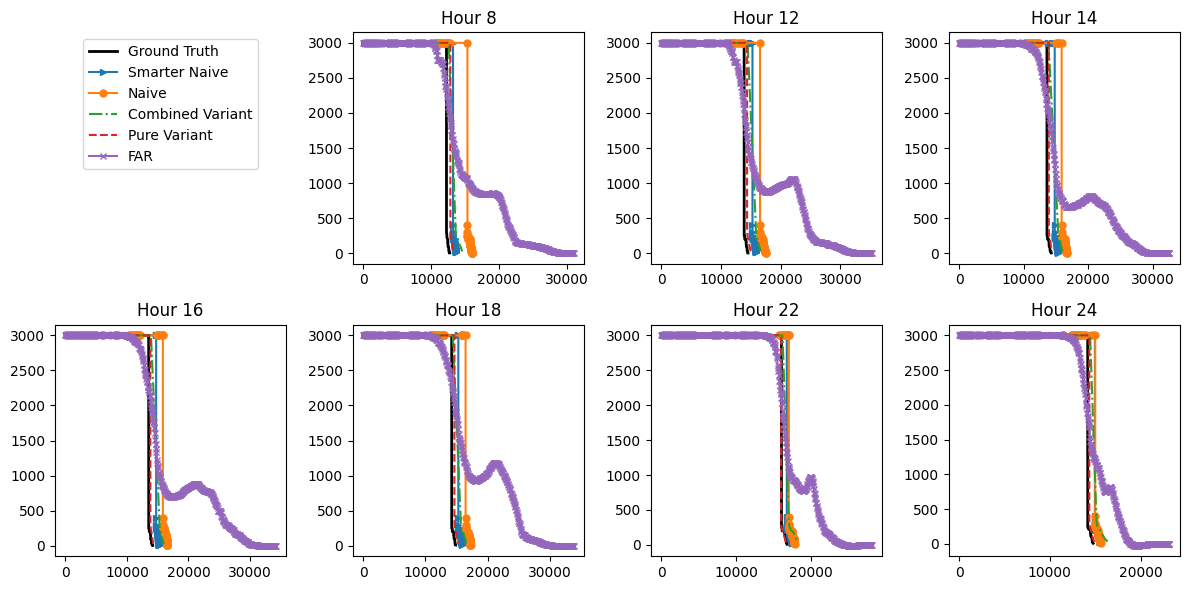

In [16]:
fig, axs = plt.subplots(2, 4, figsize=(12, 6))
hours = [3, 7, 11, 13, 15, 17, 21, 23]
# Flatten the axis array for easy iteration
axs = axs.flatten()
ax_empty = axs[0]
ax_empty.axis('off') 
idx = 10
s = 5
# Iterate over each subplot and plot something
for i, ax in enumerate(axs):
    if i > 0:
        demp = demand_price[np.arange(hours[i],len(demand_price),24)]
        demv = demand_volume[np.arange(hours[i],len(demand_price),24)]
        testv = demv[-160:]
        testp = demp[-160:]

        far_p = pd.read_csv('./FAR_curves/FAR_demand_h_' + str(hours[i]+1) + '.csv')
        far_v = pd.read_csv('./FAR_curves/FAR_demand_grid_h_' + str(hours[i]+1) + '.csv')
        
        ax.plot(testv[idx], testp[idx], color = "black", linewidth = "2.0", label = "Ground Truth")
            ax.plot(demv[len(demp) - 160 + idx - 1], demp[len(demp) - 160 + idx - 1],"->", label = "Smarter Naive", markersize=s, color = "tab:blue")
        else:
            ax.plot(demv[len(demp) - 160 + idx - 7], demp[len(demp) - 160 + idx - 7],"->", label = "Smarter Naive", markersize=s, color = "tab:blue")
        ax.plot(demv[len(demp) - 160 + idx - 1], demp[len(demp) - 160 + idx - 1],"-o", label = "Naive", markersize=s, color = "tab:orange")
        
        ax.plot(combined_predv_h_t2[hours[i]][idx],combined_predp_h_t2[hours[i]][idx], "-.", label = "Combined Variant", markersize=s, color = "tab:green")
        ax.plot(lr_predv_h[hours[i]][idx],lr_predp_h[hours[i]][idx], "--", label = "Pure Variant", markersize=s, color = "tab:red")
        ax.plot(far_v.values[:,0],far_p.values[:,idx], "-x",label = "FAR", markersize=s, color = "tab:purple")
        ax.set_title(f'Hour {hours[i]+1}')

# Adjust layout to prevent overlap
plt.tight_layout()
handles, labels = ax.get_legend_handles_labels()  # Get legend handles and labels from any non-empty subplot
ax_empty.legend(handles, labels, loc='upper center', ncol=1)  # Add legend to empty subplot
plt.show()

## Figure 11

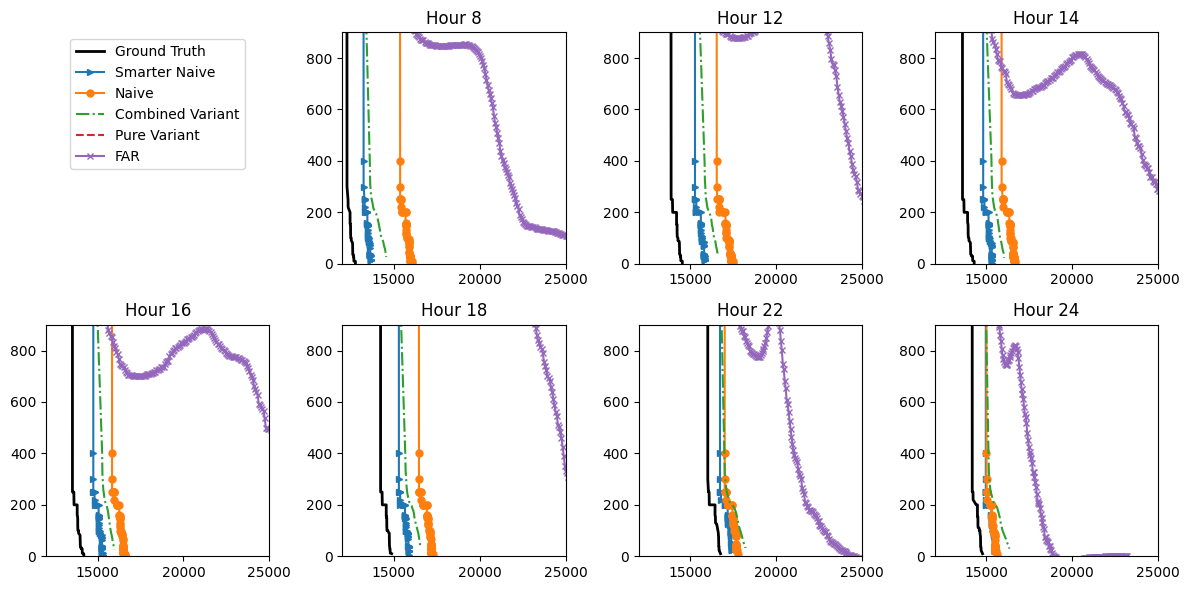

In [17]:
fig, axs = plt.subplots(2, 4, figsize=(12, 6))
hours = [3, 7, 11, 13, 15, 17, 21, 23]
# Flatten the axis array for easy iteration
axs = axs.flatten()
ax_empty = axs[0]
ax_empty.axis('off') 
idx = 10
s = 5
# Iterate over each subplot and plot something
for i, ax in enumerate(axs):
    if i > 0:
        demp = demand_price[np.arange(hours[i],len(demand_price),24)]
        demv = demand_volume[np.arange(hours[i],len(demand_price),24)]
        testv = demv[-160:]
        testp = demp[-160:]

        far_p = pd.read_csv('./FAR_curves/FAR_demand_h_' + str(hours[i]+1) + '.csv')
        far_v = pd.read_csv('./FAR_curves/FAR_demand_grid_h_' + str(hours[i]+1) + '.csv')
        
        ax.plot(testv[idx], testp[idx], color = "black", linewidth = "2.0", label = "Ground Truth")
        if vector[len(vector) - 160 + idx - 1] == 0:
            ax.plot(demv[len(demp) - 160 + idx - 1], demp[len(demp) - 160 + idx - 1],"->", label = "Smarter Naive", markersize=s, color = "tab:blue")
        else:
            ax.plot(demv[len(demp) - 160 + idx - 7], demp[len(demp) - 160 + idx - 7],"->", label = "Smarter Naive", markersize=s, color = "tab:blue")
        ax.plot(demv[len(demp) - 160 + idx - 1], demp[len(demp) - 160 + idx - 1],"-o", label = "Naive", markersize=s, color = "tab:orange")
        
        ax.plot(combined_predv_h_t2[hours[i]][idx],combined_predp_h_t2[hours[i]][idx], "-.", label = "Combined Variant", markersize=s, color = "tab:green")
        ax.plot(lr_predp_h[hours[i]][idx],lr_predv_h[hours[i]][idx], "--", label = "Pure Variant", markersize=s, color = "tab:red")
        ax.plot(far_v.values[:,0],far_p.values[:,idx], "-x",label = "FAR", markersize=s, color = "tab:purple")
        ax.set_title(f'Hour {hours[i]+1}')
        ax.set_xlim([12000, 25000])
        ax.set_ylim([0, 900])
# Adjust layout to prevent overlap
plt.tight_layout()
handles, labels = ax.get_legend_handles_labels()  # Get legend handles and labels from any non-empty subplot
ax_empty.legend(handles, labels, loc='upper center', ncol=1)  # Add legend to empty subplot
plt.show()

## Figure 12

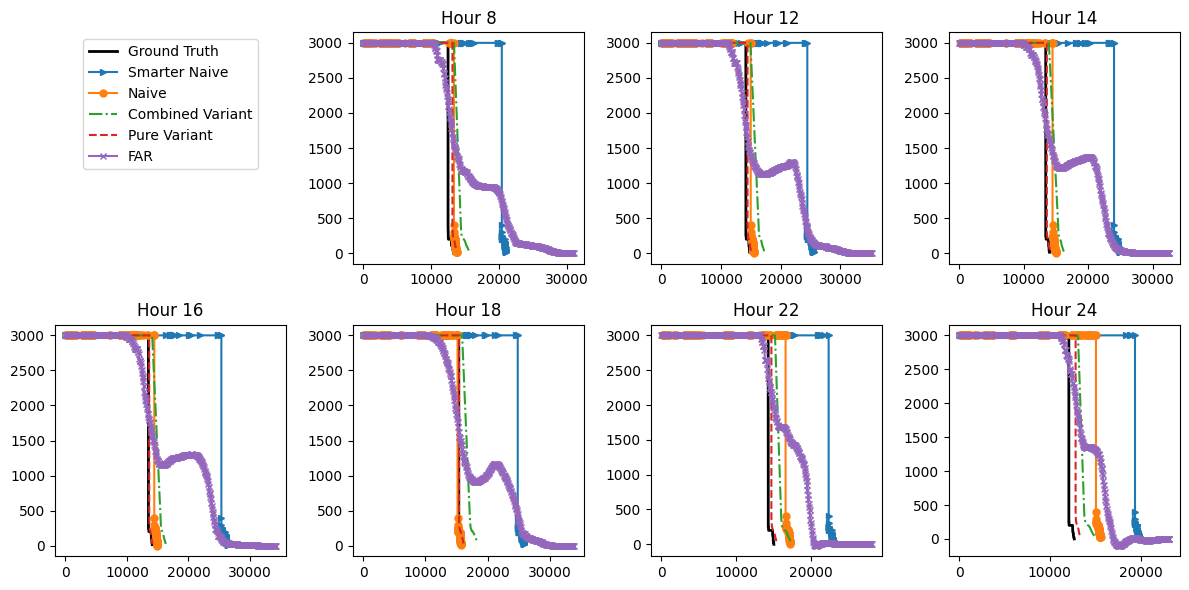

In [19]:
fig, axs = plt.subplots(2, 4, figsize=(12, 6))
hours = [3, 7, 11, 13, 15, 17, 21, 23]
# Flatten the axis array for easy iteration
axs = axs.flatten()
ax_empty = axs[0]
ax_empty.axis('off') 
idx = -10
s = 5
# Iterate over each subplot and plot something
for i, ax in enumerate(axs):
    if i > 0:
        demp = demand_price[np.arange(hours[i],len(demand_price),24)]
        demv = demand_volume[np.arange(hours[i],len(demand_price),24)]
        testv = demv[-160:]
        testp = demp[-160:]

        far_p = pd.read_csv('./FAR_curves/FAR_demand_h_' + str(hours[i]+1) + '.csv')
        far_v = pd.read_csv('./FAR_curves/FAR_demand_grid_h_' + str(hours[i]+1) + '.csv')
        
        ax.plot(testv[idx], testp[idx], color = "black", linewidth = "2.0", label = "Ground Truth")
        if vector[len(vector) - 160 + idx - 1] == 0:
            ax.plot(demv[len(demp) - 160 + idx - 1], demp[len(demp) - 160 + idx - 1],"->", label = "Smarter Naive", markersize=s, color = "tab:blue")
        else:
            ax.plot(demv[len(demp) - 160 + idx - 7], demp[len(demp) - 160 + idx - 7],"->", label = "Smarter Naive", markersize=s, color = "tab:blue")
        ax.plot(demv[len(demp) - 160 + idx - 1], demp[len(demp) - 160 + idx - 1],"-o", label = "Naive", markersize=s, color = "tab:orange")
        
        ax.plot(combined_predv_h_t2[hours[i]][idx],combined_predp_h_t2[hours[i]][idx], "-.", label = "Combined Variant", markersize=s, color = "tab:green")
        ax.plot(lr_predv_h[hours[i]][idx],lr_predp_h[hours[i]][idx], "--", label = "Pure Variant", markersize=s, color = "tab:red")
        ax.plot(far_v.values[:,0],far_p.values[:,idx], "-x",label = "FAR", markersize=s, color = "tab:purple")
        ax.set_title(f'Hour {hours[i]+1}')

# Adjust layout to prevent overlap
plt.tight_layout()
handles, labels = ax.get_legend_handles_labels()  # Get legend handles and labels from any non-empty subplot
ax_empty.legend(handles, labels, loc='upper center', ncol=1)  # Add legend to empty subplot
plt.show()

## Figure 13

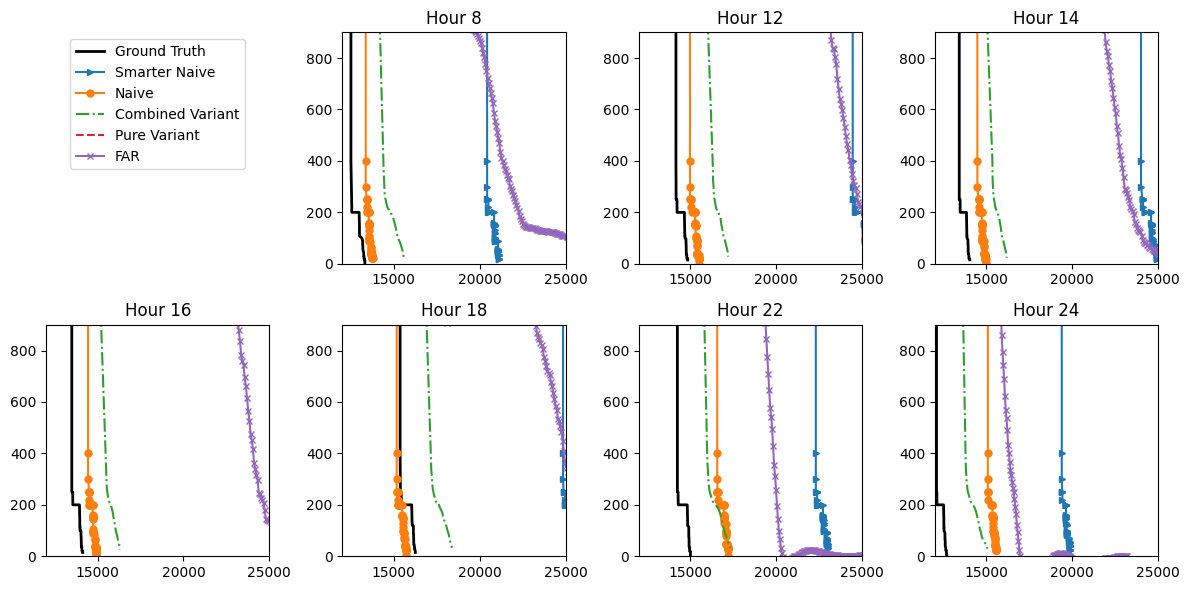

In [20]:
fig, axs = plt.subplots(2, 4, figsize=(12, 6))
hours = [3, 7, 11, 13, 15, 17, 21, 23]
# Flatten the axis array for easy iteration
axs = axs.flatten()
ax_empty = axs[0]
ax_empty.axis('off') 
idx = -10
s = 5
# Iterate over each subplot and plot something
for i, ax in enumerate(axs):
    if i > 0:
        demp = demand_price[np.arange(hours[i],len(demand_price),24)]
        demv = demand_volume[np.arange(hours[i],len(demand_price),24)]
        testv = demv[-160:]
        testp = demp[-160:]

        far_p = pd.read_csv('./FAR_curves/FAR_demand_h_' + str(hours[i]+1) + '.csv')
        far_v = pd.read_csv('./FAR_curves/FAR_demand_grid_h_' + str(hours[i]+1) + '.csv')
        
        ax.plot(testv[idx], testp[idx], color = "black", linewidth = "2.0", label = "Ground Truth")
        if vector[len(vector) - 160 + idx - 1] == 0:
            ax.plot(demv[len(demp) - 160 + idx - 1], demp[len(demp) - 160 + idx - 1],"->", label = "Smarter Naive", markersize=s, color = "tab:blue")
        else:
            ax.plot(demv[len(demp) - 160 + idx - 7], demp[len(demp) - 160 + idx - 7],"->", label = "Smarter Naive", markersize=s, color = "tab:blue")
        ax.plot(demv[len(demp) - 160 + idx - 1], demp[len(demp) - 160 + idx - 1],"-o", label = "Naive", markersize=s, color = "tab:orange")
        
        ax.plot(combined_predv_h_t2[hours[i]][idx],combined_predp_h_t2[hours[i]][idx], "-.", label = "Combined Variant", markersize=s, color = "tab:green")
        ax.plot(lr_predp_h[hours[i]][idx],lr_predv_h[hours[i]][idx], "--", label = "Pure Variant", markersize=s, color = "tab:red")
        ax.plot(far_v.values[:,0],far_p.values[:,idx], "-x",label = "FAR", markersize=s, color = "tab:purple")
        ax.set_title(f'Hour {hours[i]+1}')
        ax.set_xlim([12000, 25000])
        ax.set_ylim([0, 900])
# Adjust layout to prevent overlap
plt.tight_layout()
handles, labels = ax.get_legend_handles_labels()  # Get legend handles and labels from any non-empty subplot
ax_empty.legend(handles, labels, loc='upper center', ncol=1)  # Add legend to empty subplot
plt.show()

## Supply

### Linear Autoregression Function

In [37]:
def model_1(P):
    # Create lag-1 covariate: value at t-1
    P_x = P[6:-1].reshape(len(P[6:-1]), 1)
    
    # Target variable: value at t
    P_y = P[7:].reshape(len(P[7:]), 1)
    
    # Add bias term (intercept)
    bias = np.ones((len(P_x), 1))

    # Stack covariate with bias
    P_covariate = np.hstack((P_x, bias))
    P_target = P_y

    # Train-test split (last 172 used for testing)
    x_train = P_covariate[:-172, :]
    x_test = P_covariate[-172:, :]
    
    # Split training into training and validation (69.6% for training)
    split = int(0.696 * len(x_train))
    x_valid = x_train[split:]
    x_train = x_train[:split]

    # Split target variable accordingly
    y_train = P_target[:-172, :]
    y_test = P_target[-172:, :]
    split = int(0.696 * len(y_train))
    y_valid = y_train[split:]
    y_train = y_train[:split]

    # Hyperparameter tuning for Lasso regression using validation RMSE
    mini = 99999999999  # Initialize minimum RMSE
    min_alpha = 0       # Best alpha to be determined
    
    for i in np.linspace(1, 200, 1000):
        lasso = Lasso(alpha=i)  # Set regularization strength
        lasso.fit(x_train, y_train)
        y_pred = lasso.predict(x_valid)
        if np.sqrt(mean_squared_error(y_valid, y_pred)) < mini:
            mini = np.sqrt(mean_squared_error(y_valid, y_pred))
            min_alpha = i

    # Train Lasso model with best alpha
    lasso = Lasso(alpha=min_alpha)
    lasso.fit(x_train, y_train)

    # Predict and stack predictions for all sets (train, valid, test)
    P_lr = np.hstack((lasso.predict(x_train), lasso.predict(x_valid)))
    P_lr = np.hstack((P_lr, lasso.predict(x_test)))

    # Final test prediction
    P_pred_lr = lasso.predict(x_test)

    # Return validation predictions, test targets, and test predictions
    return lasso.predict(x_valid), y_test, P_pred_lr

In [39]:
def metric(x1, y1, x2, y2):
    # Define a common interpolation grid
    temp = np.sort(np.unique(np.union1d(x1,x2)))
    v = np.linspace(temp[0],x1[-1],10000)
    
    # Interpolate both curves
    c1 = np.interp(v,x1,y1)
    c2 = np.interp(v,x2,y2)
    
    # Compute RMSE between curves
    area = np.sqrt(np.mean((c1 - c2)**2))
    return area


class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        # Input to hidden layer
        self.fc1 = nn.Linear(200, 164)
        # Hidden to output layer
        self.fc3 = nn.Linear(164, 200)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc3(x)
        return x


sup_lr_predv_h = []
sup_lr_predp_h = []

sup_combined_predv_h_t2 = []
sup_combined_predp_h_t2 = []

sup_coef_h_2 = []

for h in range(24):
    sup_P = []
    sup_Q = []
    sup_K = []

    # Extract supply curves for hour h
    supp = supply_price[np.arange(h,len(supply_price),24)]
    supv = supply_volume[np.arange(h,len(supply_price),24)]

    # Replace problematic 3000 prices
    for i in range(len(supv)):
        supv[i][supp[i] == 3000] = [supv[i][supp[i] == 3000][0]]
        supp[i][supp[i] == 3000] = [supp[i][supp[i] == 3000][0]]

    # Decompose curves into points P, Q, K
    for i in range(len(supp)):
        sup_P.append(supv[i][0])
        sup_Q.append(supv[i][supp[i]<3000][-1])
        sup_K.append(supv[i][supp[i]==3000][0])

    sup_P = np.array(sup_P)
    sup_Q = np.array(sup_Q)
    sup_K = np.array(sup_K)

    #### Linear Regression forecasts
    sup_P_lr_val_train = model_1(sup_P)[0][7:]    
    sup_Q_lr_val_train = model_1(sup_Q)[0][7:]
    sup_K_lr_val_train = model_1(sup_K)[0][7:]

    sup_P_lr_val_test = model_1(sup_P)[-1] 
    sup_Q_lr_val_test = model_1(sup_Q)[-1]
    sup_K_lr_val_test = model_1(sup_K)[-1]

    ### Smarter Naive forecasts
    split = 7
    testv = supv[split:].copy()
    testp = supp[split:].copy()

    sm_sup_P = []
    sm_sup_Q = []
    sm_sup_K = []

    sm_predv = []
    sm_predp = []

    # Naive strategy using previous day
    for i in range(split, len(testv)):
        sm_sup_P.append(supv[i - 1][0])
        sm_sup_Q.append(supv[i - 1][supp[i - 1]<3000][-1])
        sm_sup_K.append(supv[i - 1][supp[i - 1]==3000][0])
        sm_predv.append(supv[i - 1])
        sm_predp.append(supp[i - 1])

    sm_sup_P = np.array(sm_sup_P)
    sm_sup_Q = np.array(sm_sup_Q)
    sm_sup_K = np.array(sm_sup_K)

    sup_P_sm_val_test = sm_sup_P[-172:]
    sup_Q_sm_val_test = sm_sup_Q[-172:]
    sup_K_sm_val_test = sm_sup_K[-172:]

    #### Segment curve dataset
    testv = supv[-172:]
    testp = supp[-172:]

    valv = supv[-len(sup_P_lr_val_train)-172:-172]
    valp = supp[-len(sup_P_lr_val_train)-172:-172]

    sm_curve_p_val = []
    sm_curve_p_test = []

    for i in range(-len(sup_P_lr_val_train)-172,-172):
        sm_curve_p_val.append(sm_predp[i][sm_predp[i]<3000])

    for i in range(len(sm_predp)-172,len(sm_predp)):
        sm_curve_p_test.append(sm_predp[i][sm_predp[i]<3000])

    sup_P_sm_val_train = sm_sup_P[-len(sup_P_lr_val_train)-172:-172]
    sup_Q_sm_val_train = sm_sup_Q[-len(sup_Q_lr_val_train)-172:-172]
    sup_K_sm_val_train = sm_sup_K[-len(sup_K_lr_val_train)-172:-172]

    sup_P_valid_target = sup_P[-len(sup_P_lr_val_train)-172:-172]
    sup_Q_valid_target = sup_Q[-len(sup_Q_lr_val_train)-172:-172]
    sup_K_valid_target = sup_K[-len(sup_K_lr_val_train)-172:-172]

    sup_P_test_target = sup_P[-172:]
    sup_Q_test_target = sup_Q[-172:]
    sup_K_test_target = sup_K[-172:]

    ## Prepare training and validation curves
    c_p = []
    for i in range(len(supp)):
        tp = (supp[i][supp[i]<3000])
        tv = (supv[i][supp[i]<3000])
        grid = np.linspace(tv[0], tv[-1], num = 200)
        c_p.append(np.interp(grid, tv, tp))
    c_p = np.array(c_p)

    train = c_p[:-172]
    test = c_p[-173:]
    d_train = public_holidays[:-172]
    d_test = public_holidays[-172:]

    split = int(0.7*len(train))

    valid = train[split-1:]
    d_valid = d_train[split:]
    train = train[:split]
    d_train = d_train[:split]

    # Build supervised dataset (X, Y) from curve sequences
    x_train = train[0:-1]
    y_train = train[1:]
    du_train = d_train[1:]

    x_test = test[0:-1]
    y_test = test[1:]
    du_test = d_test

    x_valid = valid[0:-1]
    y_valid = valid[1:]
    du_valid = d_valid

    # Initialize and train simple NN model
    model = SimpleNN()
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters())

    X_train_tensor = torch.tensor(x_train, dtype=torch.float)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float)

    num_epochs = 100
    batch_size = 32

    for epoch in range(num_epochs):
        for i in range(0, len(x_train), batch_size):
            inputs = X_train_tensor[i:i+batch_size]
            targets = y_train_tensor[i:i+batch_size]

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    X_test_tensor = torch.tensor(x_test, dtype=torch.float)
    X_valid_tensor = torch.tensor(x_valid, dtype=torch.float)

    model.eval()
    with torch.no_grad():
        outputs_test = model(X_valid_tensor)
    Y_valid = outputs_test.numpy()

    model.eval()
    with torch.no_grad():
        outputs_test = model(X_test_tensor)
    Y_test = outputs_test.numpy()

    # Objective function for differential evolution (2 param version)
    def objective(n):
        sup_P_h = n[0]*sup_P_sm_val_train + n[1]*sup_P_lr_val_train
        sup_Q_h = n[0]*sup_Q_sm_val_train + n[1]*sup_Q_lr_val_train
        sup_K_h = n[0]*sup_K_sm_val_train + n[1]*sup_K_lr_val_train

        comb_loss = []
        for i in range(len(valv)):
            sup_P_t = sup_P_h[i]
            sup_Q_t = sup_Q_h[i]
            sup_K_t = sup_K_h[i]

            curve = Y_valid[7:][i]
            pred = reconstruct_sup(sup_P_t,sup_Q_t,sup_K_t,curve)
            comb_loss.append(metric(valv[i],valp[i],pred[0],pred[1]))
        rmse = np.mean(comb_loss)
        return rmse

    # Results for the Pure Variant
    n = [0, 1]
    sup_P_h = n[0]*sup_P_sm_val_test[12:] + n[1]*sup_P_lr_val_test[12:]
    sup_Q_h = n[0]*sup_Q_sm_val_test[12:] + n[1]*sup_Q_lr_val_test[12:]
    sup_K_h = n[0]*sup_K_sm_val_test[12:] + n[1]*sup_K_lr_val_test[12:]

    lr_predv = []
    lr_predp = []

    for i in range(len(testv)-12):
        sup_P_t = sup_P_h[i]
        sup_Q_t = sup_Q_h[i]
        sup_K_t = sup_K_h[i]
        curve = Y_test[12:][i]
        pred = reconstruct_sup(sup_P_t,sup_Q_t,sup_K_t,curve)
        lr_predv.append(pred[0])
        lr_predp.append(pred[1])

    sup_lr_predp_h.append(lr_predp)
    sup_lr_predv_h.append(lr_predv)

    # Objective function for 5-parameter DE optimization
    def objective(n):
        sup_P_h = n[0]*sup_P_sm_val_train + n[1]*sup_P_lr_val_train + n[2]
        sup_Q_h = n[0]*sup_Q_sm_val_train + n[1]*sup_Q_lr_val_train + n[3]
        sup_K_h = n[0]*sup_K_sm_val_train + n[1]*sup_K_lr_val_train + n[4]

        comb_loss = []
        for i in range(len(valv)):
            sup_P_t = sup_P_h[i]
            sup_Q_t = sup_Q_h[i]
            sup_K_t = sup_K_h[i]

            curve = Y_valid[7:][i]
            pred = reconstruct_sup(sup_P_t,sup_Q_t,sup_K_t,curve)
            comb_loss.append(metric(valv[i],valp[i],pred[0],pred[1]))
        rmse = np.mean(comb_loss)
        return rmse

    bounds = [(0, 1),(0, 1),(-1000,1000),(-1000,1000),(-1000,1000)]

    # Differential Evolution configuration
    popsize = 0
    maxiter = 0

    result = differential_evolution(objective, bounds, popsize=popsize, maxiter=maxiter,
                                    mutation=(0.5, 1.0), strategy='best1bin', seed=42)

    optimized_params = result.x

    predictionp = []
    predictionv = []
    n = result.x

    # Apply optimized weights
    sup_P_h = n[0]*sup_P_sm_val_test[12:] + n[1]*sup_P_lr_val_test[12:] + n[2]
    sup_Q_h = n[0]*sup_Q_sm_val_test[12:] + n[1]*sup_Q_lr_val_test[12:] + n[3]
    sup_K_h = n[0]*sup_K_sm_val_test[12:] + n[1]*sup_K_lr_val_test[12:] + n[4]

    comb_loss = []
    for i in range(len(testv)-12):
        sup_P_t = sup_P_h[i]
        sup_Q_t = sup_Q_h[i]
        sup_K_t = sup_K_h[i]
        curve = Y_test[12:][i]
        pred = reconstruct_sup(sup_P_t,sup_Q_t,sup_K_t,curve)
        predictionp.append(pred[1])
        predictionv.append(pred[0])

    sup_combined_predv_h_t2.append(predictionv)
    sup_combined_predp_h_t2.append(predictionp)


### Saving the results

In [83]:
sup_combined_predv_h_t2 = np.array(sup_combined_predv_h_t2)
sup_combined_predp_h_t2 = np.array(sup_combined_predp_h_t2)

sup_lr_predv_h = np.array(sup_lr_predv_h)
sup_lr_predp_h = np.array(sup_lr_predp_h)
np.save("Results/Supply_comb_v.npy",sup_combined_predv_h_t2)
np.save("Results/Supply_comb_p.npy",sup_combined_predp_h_t2)

np.save("Results/Supply_pure_v.npy",sup_lr_predv_h)
np.save("Results/Supply_pure_p.npy",sup_lr_predp_h)

### Seasonal Results

In [24]:
## Loading the results

sup_combined_predv_h_t2 = np.load("Results/Supply_comb_v.npy")
sup_combined_predp_h_t2 = np.load("Results/Supply_comb_p.npy")

sup_lr_predv_h = np.load("Results/Supply_pure_v.npy")
sup_lr_predp_h = np.load("Results/Supply_pure_p.npy")

#### Full test period

In [25]:
def metric(x1, y1, x2, y2):
    # Define a common interpolation grid between two x-domains
    temp = np.sort(np.unique(np.union1d(x1,x2)))
    v = np.linspace(temp[0], x1[-1], 10000)

    # Interpolate both curves on the common grid
    c1 = np.interp(v, x1, y1)
    c2 = np.interp(v, x2, y2)

    # Compute RMSE between the interpolated curves
    area = np.sqrt(np.mean((c1 - c2)**2))
    return area


for h in range(24):
    # Extract hourly supply curves
    supp = supply_price[np.arange(h, len(supply_price), 24)]
    supv = supply_volume[np.arange(h, len(supply_price), 24)]
    
    start = 0
    end = 160  # Evaluate the last 160 samples

    split = 7  # Used for lag logic (1-day or 7-day smarter naive)
    testv = supv[split:]
    testp = supp[split:]
    j = split

    sm_predv = []
    sm_predp = []

    # Generate smarter naive predictions using either lag-1 or lag-7
    for i in range(len(testv)):
        if vector[i + split] == 0:
            sm_predv.append(supv[j - 1])  # Use previous day's volume
            sm_predp.append(supp[j - 1])  # Use previous day's price
        else:
            sm_predv.append(supv[j - 7])  # Use last week's volume
            sm_predp.append(supp[j - 7])  # Use last week's price
        j += 1

    # Define test window
    testv = supv[-160:]
    testp = supp[-160:]

    # Apply start:end slicing on test sets
    testv = testv[start:end]
    testp = testp[start:end]

    # Naive predictions from the previous day
    predv = supv[-161:-1][start:end]
    predp = supp[-161:-1][start:end]

    # Evaluate naive baseline using metric
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], predv[i], predp[i]))
    rmse_n = np.mean(comb_loss)

    # Evaluate smarter naive baseline
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(
            testv[i], testp[i],
            sm_predv[-160:][start:end][i], sm_predp[-160:][start:end][i]
        ))
    rmse_sm = np.mean(comb_loss)

    # Load FAR model predictions for the current hour
    far_p = pd.read_csv('./FAR_curves/FAR_supply_h_' + str(h+1) + '.csv')
    far_v = pd.read_csv('./FAR_curves/FAR_supply_grid_h_' + str(h+1) + '.csv')

    # Evaluate FAR model
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], far_v.values[:, 0], far_p.values[:, i]))
    rmse_far = round(np.mean(comb_loss), 2)

    # Evaluate linear regression model (sup_lr)
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], sup_lr_predv_h[h][i], sup_lr_predp_h[h][i]))
    rmse_lr = np.mean(comb_loss)

    # Evaluate combined model (optimized via differential evolution)
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], sup_combined_predv_h_t2[h][i], sup_combined_predp_h_t2[h][i]))
    rmse = np.mean(comb_loss)

    # Print RMSEs for each model for the current hour
    print(
        str(h + 1) + "  " +
        str(round(rmse_n, 2)) + "  " +
        str(round(rmse_sm, 2)) + "  " +
        str(rmse_far) + "  " +
        str(round(rmse_lr, 2)) + "  " +
        str(round(rmse, 2))
    )


1  142.62  155.7  145.65  142.15  136.86
2  122.94  124.36  131.51  124.96  119.89
3  122.56  126.03  130.58  123.18  122.49
4  119.01  125.17  128.05  120.2  118.89
5  116.11  135.87  111.56  111.55  107.12
6  109.17  131.49  105.6  104.56  99.16
7  102.85  129.18  99.78  96.81  92.14
8  127.67  137.71  122.68  121.0  104.71
9  140.71  137.4  133.1  122.65  114.55
10  142.21  141.4  134.71  126.71  115.75
11  142.93  147.97  135.32  127.5  121.23
12  143.45  156.27  134.91  132.47  120.51
13  135.9  154.82  129.09  129.31  120.25
14  136.73  154.21  128.48  129.55  120.8
15  133.1  148.85  124.06  124.46  112.39
16  129.51  140.5  121.94  119.5  108.45
17  129.66  130.67  121.24  117.76  107.8
18  126.7  130.46  121.97  111.92  101.58
19  123.6  126.54  120.67  103.95  98.64
20  113.4  125.84  114.52  98.5  94.42
21  110.37  127.02  111.63  99.56  96.01
22  101.96  130.03  102.77  98.38  90.64
23  97.19  133.27  102.8  99.36  90.01
24  95.16  127.51  100.27  99.71  89.07


#### Summer

In [26]:
def metric(x1, y1, x2, y2):
    # Define a common interpolation grid between two x-domains
    temp = np.sort(np.unique(np.union1d(x1,x2)))
    v = np.linspace(temp[0], x1[-1], 10000)

    # Interpolate both curves on the common grid
    c1 = np.interp(v, x1, y1)
    c2 = np.interp(v, x2, y2)

    # Compute RMSE between the interpolated curves
    area = np.sqrt(np.mean((c1 - c2)**2))
    return area


for h in range(24):
    # Extract hourly supply curves
    supp = supply_price[np.arange(h, len(supply_price), 24)]
    supv = supply_volume[np.arange(h, len(supply_price), 24)]
    
    start = 0
    end = 80  # Evaluate the first 80 samples

    split = 7  # Used for lag logic (1-day or 7-day smarter naive)
    testv = supv[split:]
    testp = supp[split:]
    j = split

    sm_predv = []
    sm_predp = []

    # Generate smarter naive predictions using either lag-1 or lag-7
    for i in range(len(testv)):
        if vector[i + split] == 0:
            sm_predv.append(supv[j - 1])  # Use previous day's volume
            sm_predp.append(supp[j - 1])  # Use previous day's price
        else:
            sm_predv.append(supv[j - 7])  # Use last week's volume
            sm_predp.append(supp[j - 7])  # Use last week's price
        j += 1

    # Define test window
    testv = supv[-160:]
    testp = supp[-160:]

    # Apply start:end slicing on test sets
    testv = testv[start:end]
    testp = testp[start:end]

    # Naive predictions from the previous day
    predv = supv[-161:-1][start:end]
    predp = supp[-161:-1][start:end]

    # Evaluate naive baseline using metric
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], predv[i], predp[i]))
    rmse_n = np.mean(comb_loss)

    # Evaluate smarter naive baseline
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(
            testv[i], testp[i],
            sm_predv[-160:][start:end][i], sm_predp[-160:][start:end][i]
        ))
    rmse_sm = np.mean(comb_loss)

    # Load FAR model predictions for the current hour
    far_p = pd.read_csv('./FAR_curves/FAR_supply_h_' + str(h+1) + '.csv')
    far_v = pd.read_csv('./FAR_curves/FAR_supply_grid_h_' + str(h+1) + '.csv')

    # Evaluate FAR model
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], far_v.values[:, 0], far_p.values[:, i]))
    rmse_far = round(np.mean(comb_loss), 2)

    # Evaluate linear regression model (sup_lr)
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], sup_lr_predv_h[h][i], sup_lr_predp_h[h][i]))
    rmse_lr = np.mean(comb_loss)

    # Evaluate combined model (optimized via differential evolution)
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], sup_combined_predv_h_t2[h][i], sup_combined_predp_h_t2[h][i]))
    rmse = np.mean(comb_loss)

    # Print RMSEs for each model for the current hour
    print(
        str(h + 1) + "  " +
        str(round(rmse_n, 2)) + "  " +
        str(round(rmse_sm, 2)) + "  " +
        str(rmse_far) + "  " +
        str(round(rmse_lr, 2)) + "  " +
        str(round(rmse, 2))
    )


1  128.66  139.17  135.61  131.17  125.85
2  123.07  121.05  131.21  123.06  118.03
3  125.48  125.5  132.26  124.88  124.58
4  124.47  125.46  131.19  123.66  123.49
5  123.44  124.48  110.03  112.21  107.61
6  118.15  123.35  105.27  106.46  100.55
7  111.65  116.41  107.61  98.23  91.44
8  122.07  117.87  117.17  114.58  93.53
9  136.59  110.21  128.05  115.3  101.91
10  138.66  116.95  128.84  119.38  104.08
11  138.13  123.16  128.76  120.42  109.76
12  135.76  128.05  128.02  123.67  106.75
13  130.74  128.0  123.19  117.67  106.38
14  132.0  127.99  123.43  118.95  108.77
15  127.55  122.74  120.02  116.49  102.22
16  131.16  122.59  123.3  115.68  104.08
17  134.89  122.48  124.66  113.37  103.89
18  128.92  115.33  126.54  110.4  94.08
19  120.81  106.3  121.43  96.38  87.41
20  104.15  103.21  110.94  89.72  79.69
21  99.64  101.14  108.72  89.77  81.76
22  101.2  109.76  107.59  90.71  81.77
23  97.27  119.04  108.98  93.54  83.38
24  95.98  116.23  105.84  100.13  85.82


#### Winter

In [27]:
def metric(x1, y1, x2, y2):
    # Define a common interpolation grid between two x-domains
    temp = np.sort(np.unique(np.union1d(x1,x2)))
    v = np.linspace(temp[0], x1[-1], 10000)

    # Interpolate both curves on the common grid
    c1 = np.interp(v, x1, y1)
    c2 = np.interp(v, x2, y2)

    # Compute RMSE between the interpolated curves
    area = np.sqrt(np.mean((c1 - c2)**2))
    return area


for h in range(24):
    # Extract hourly supply curves
    supp = supply_price[np.arange(h, len(supply_price), 24)]
    supv = supply_volume[np.arange(h, len(supply_price), 24)]
    
    start = 80
    end = 160  # Evaluate the last 80 samples

    split = 7  # Used for lag logic (1-day or 7-day smarter naive)
    testv = supv[split:]
    testp = supp[split:]
    j = split

    sm_predv = []
    sm_predp = []

    # Generate smarter naive predictions using either lag-1 or lag-7
    for i in range(len(testv)):
        if vector[i + split] == 0:
            sm_predv.append(supv[j - 1])  # Use previous day's volume
            sm_predp.append(supp[j - 1])  # Use previous day's price
        else:
            sm_predv.append(supv[j - 7])  # Use last week's volume
            sm_predp.append(supp[j - 7])  # Use last week's price
        j += 1

    # Define test window
    testv = supv[-160:]
    testp = supp[-160:]

    # Apply start:end slicing on test sets
    testv = testv[start:end]
    testp = testp[start:end]

    # Naive predictions from the previous day
    predv = supv[-161:-1][start:end]
    predp = supp[-161:-1][start:end]

    # Evaluate naive baseline using metric
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], predv[i], predp[i]))
    rmse_n = np.mean(comb_loss)

    # Evaluate smarter naive baseline
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(
            testv[i], testp[i],
            sm_predv[-160:][start:end][i], sm_predp[-160:][start:end][i]
        ))
    rmse_sm = np.mean(comb_loss)

    # Load FAR model predictions for the current hour
    far_p = pd.read_csv('./FAR_curves/FAR_supply_h_' + str(h+1) + '.csv')
    far_v = pd.read_csv('./FAR_curves/FAR_supply_grid_h_' + str(h+1) + '.csv')

    # Evaluate FAR model
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], far_v.values[:, 0], far_p.values[:, i]))
    rmse_far = round(np.mean(comb_loss), 2)

    # Evaluate linear regression model (sup_lr)
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], sup_lr_predv_h[h][i], sup_lr_predp_h[h][i]))
    rmse_lr = np.mean(comb_loss)

    # Evaluate combined model (optimized via differential evolution)
    comb_loss = []
    for i in range(len(testv)):
        comb_loss.append(metric(testv[i], testp[i], sup_combined_predv_h_t2[h][i], sup_combined_predp_h_t2[h][i]))
    rmse = np.mean(comb_loss)

    # Print RMSEs for each model for the current hour
    print(
        str(h + 1) + "  " +
        str(round(rmse_n, 2)) + "  " +
        str(round(rmse_sm, 2)) + "  " +
        str(rmse_far) + "  " +
        str(round(rmse_lr, 2)) + "  " +
        str(round(rmse, 2))
    )


1  156.57  172.22  155.7  153.13  147.86
2  122.82  127.67  131.82  126.85  121.75
3  119.64  126.56  128.91  121.48  120.4
4  113.54  124.88  124.92  116.73  114.3
5  108.78  147.27  113.08  110.89  106.63
6  100.2  139.63  105.93  102.66  97.76
7  94.05  141.95  91.94  95.39  92.83
8  133.28  157.55  128.18  127.42  115.89
9  144.83  164.6  138.16  130.0  127.2
10  145.76  165.85  140.58  134.05  127.42
11  147.73  172.78  141.87  134.59  132.69
12  151.14  184.5  141.79  141.27  134.27
13  141.07  181.63  134.98  140.96  134.12
14  141.46  180.43  133.53  140.15  132.83
15  138.64  174.96  128.1  132.44  122.55
16  127.85  158.42  120.58  123.31  112.81
17  124.43  138.85  117.82  122.15  111.7
18  124.48  145.59  117.4  113.44  109.07
19  126.38  146.78  119.9  111.53  109.88
20  122.64  148.46  118.11  107.28  109.15
21  121.1  152.9  114.54  109.35  110.26
22  102.72  150.29  97.96  106.05  99.52
23  97.11  147.49  96.62  105.18  96.65
24  94.34  138.8  94.71  99.29  92.31


## Figure 14

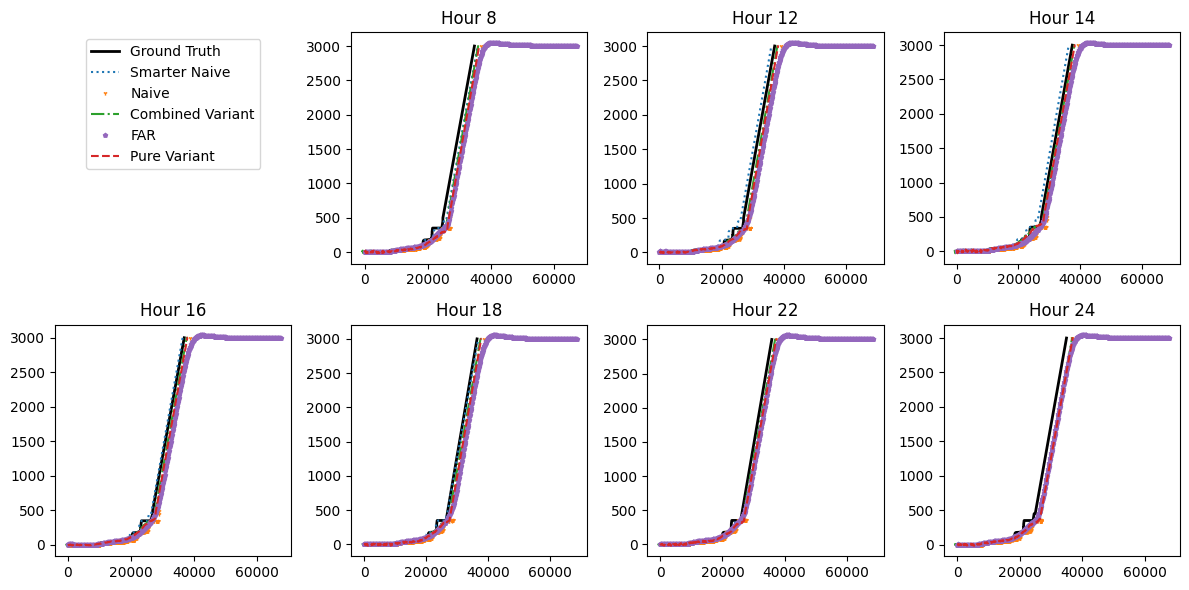

In [28]:
fig, axs = plt.subplots(2, 4, figsize=(12, 6))
hours = [3, 7, 11, 13, 15, 17, 21, 23]
# Flatten the axis array for easy iteration
axs = axs.flatten()
ax_empty = axs[0]
ax_empty.axis('off') 
idx = 10
s = 3

# Iterate over each subplot and plot something
for i, ax in enumerate(axs):
    if i > 0:
        supp = supply_price[np.arange(hours[i],len(supply_price),24)]
        supv = supply_volume[np.arange(hours[i],len(supply_price),24)]
        testv = supv[-160:]
        testp = supp[-160:]

        far_p = pd.read_csv('./FAR_curves/FAR_supply_h_' + str(hours[i]+1) + '.csv')
        far_v = pd.read_csv('./FAR_curves/FAR_supply_grid_h_' + str(hours[i]+1) + '.csv')
    
        
        ax.plot(testv[idx], testp[idx], color = "black", linewidth = "2.0", label = "Ground Truth") 
        if vector[len(vector) - 160 + idx - 1] == 0:
            ax.plot(supv[len(supp) - 160 + idx - 1], supp[len(supp) - 160 + idx - 1], ":", label = "Smarter Naive", markersize = s, color = "tab:blue")
        else:
            ax.plot(supv[len(supp) - 160 + idx - 7], supp[len(supp) - 160 + idx - 7], ":", label = "Smarter Naive", markersize = s, color = "tab:blue")
        #ax.plot(supv[len(supp) - 160 + idx - 1], supp[len(supp) - 160 + idx - 1], label = "Naive")
        ax.plot(supv[len(supp) - 160 + idx - 1], supp[len(supp) - 160 + idx - 1], "1", label = "Naive", markersize = s, color = "tab:orange")
        ax.plot(sup_combined_predv_h_t2[hours[i]][idx],sup_combined_predp_h_t2[hours[i]][idx], "-.", label = "Combined Variant", markersize = s, color = "tab:green")
        ax.plot(far_v.values[:,0],far_p.values[:,idx], "p", label = "FAR", markersize = s, color = "tab:purple")
        ax.plot(sup_lr_predv_h[hours[i]][idx],sup_lr_predp_h[hours[i]][idx], "--", label = "Pure Variant", markersize = s, color = "tab:red")
        ax.set_title(f'Hour {hours[i]+1}')

# Adjust layout to prevent overlap
plt.tight_layout()
handles, labels = ax.get_legend_handles_labels()  # Get legend handles and labels from any non-empty subplot
ax_empty.legend(handles, labels, loc='upper center', ncol=1)  # Add legend to empty subplot

plt.show()

## Figure 15

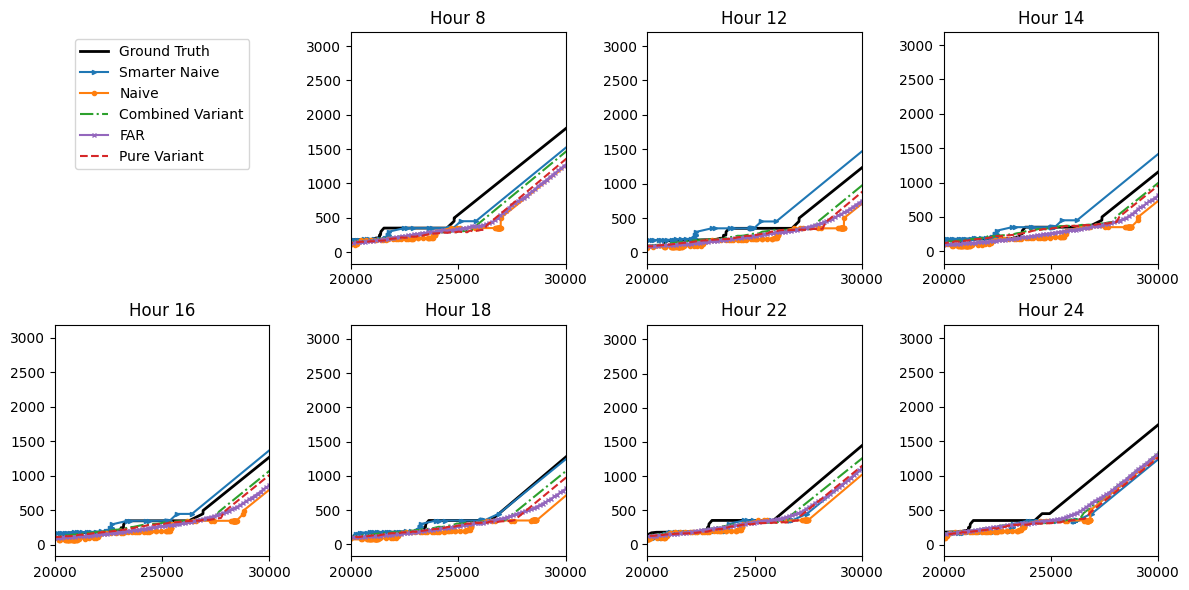

In [30]:
fig, axs = plt.subplots(2, 4, figsize=(12, 6))
hours = [3, 7, 11, 13, 15, 17, 21, 23]
# Flatten the axis array for easy iteration
axs = axs.flatten()
ax_empty = axs[0]
ax_empty.axis('off') 
idx = 10
s = 3
# Iterate over each subplot and plot something
for i, ax in enumerate(axs):
    if i > 0:
        supp = supply_price[np.arange(hours[i],len(supply_price),24)]
        supv = supply_volume[np.arange(hours[i],len(supply_price),24)]
        testv = supv[-160:]
        testp = supp[-160:]

        far_p = pd.read_csv('./FAR_curves/FAR_supply_h_' + str(hours[i]+1) + '.csv')
        far_v = pd.read_csv('./FAR_curves/FAR_supply_grid_h_' + str(hours[i]+1) + '.csv')
    
        
        ax.plot(testv[idx], testp[idx], color = "black", linewidth = "2.0", label = "Ground Truth") 
        if vector[len(vector) - 160 + idx - 1] == 0:
            ax.plot(supv[len(supp) - 160 + idx - 1], supp[len(supp) - 160 + idx - 1], "->", label = "Smarter Naive", markersize = s, color = "tab:blue")
        else:
            ax.plot(supv[len(supp) - 160 + idx - 7], supp[len(supp) - 160 + idx - 7], "->", label = "Smarter Naive", markersize = s, color = "tab:blue")
        #ax.plot(supv[len(supp) - 160 + idx - 1], supp[len(supp) - 160 + idx - 1], label = "Naive")
        ax.plot(supv[len(supp) - 160 + idx - 1], supp[len(supp) - 160 + idx - 1], "-o", label = "Naive", markersize = s, color = "tab:orange")
        ax.plot(sup_combined_predv_h_t2[hours[i]][idx],sup_combined_predp_h_t2[hours[i]][idx], "-.", label = "Combined Variant", markersize = s, color = "tab:green")
        ax.plot(far_v.values[:,0],far_p.values[:,idx], "-x", label = "FAR", markersize = s, color = "tab:purple")
        ax.plot(sup_lr_predv_h[hours[i]][idx],sup_lr_predp_h[hours[i]][idx], "--", label = "Pure Variant", markersize = s, color = "tab:red")
        ax.set_title(f'Hour {hours[i]+1}')
        ax.set_xlim([20000,30000])
        ax.set_xticks(np.linspace(20000, 30000, 3, dtype=int))
# Adjust layout to prevent overlap
plt.tight_layout()
handles, labels = ax.get_legend_handles_labels()  # Get legend handles and labels from any non-empty subplot
ax_empty.legend(handles, labels, loc='upper center', ncol=1)  # Add legend to empty subplot

# Show the plot
plt.show()

## Figure 16 

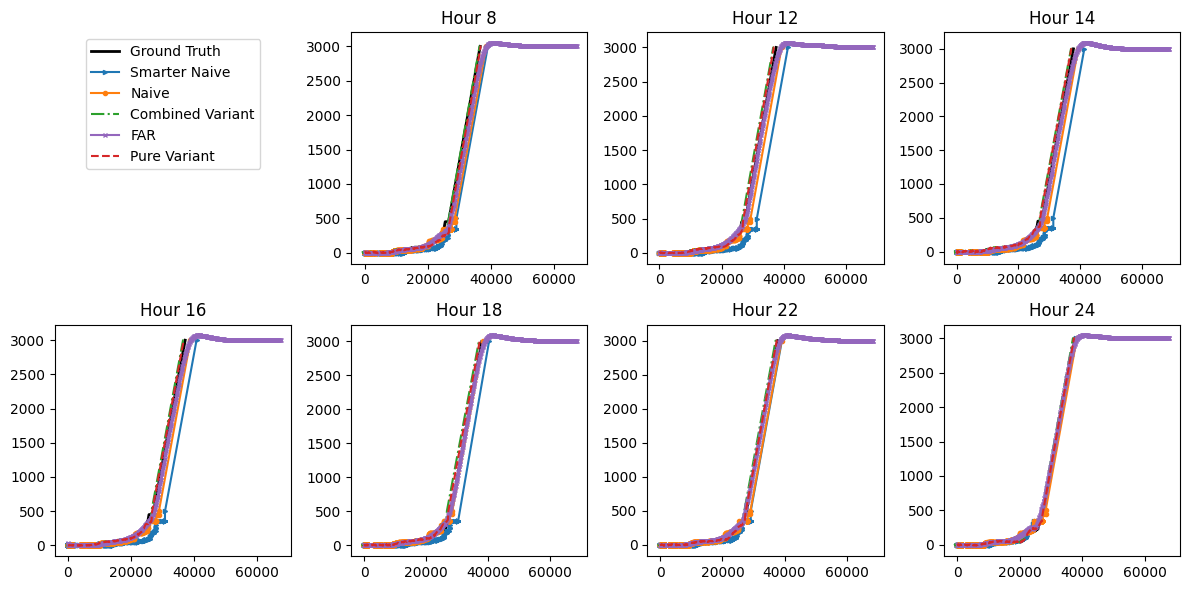

In [31]:
fig, axs = plt.subplots(2, 4, figsize=(12, 6))
hours = [3, 7, 11, 13, 15, 17, 21, 23]
# Flatten the axis array for easy iteration
axs = axs.flatten()
ax_empty = axs[0]
ax_empty.axis('off') 
idx = -10
s = 3
# Iterate over each subplot and plot something
for i, ax in enumerate(axs):
    if i > 0:
        supp = supply_price[np.arange(hours[i],len(supply_price),24)]
        supv = supply_volume[np.arange(hours[i],len(supply_price),24)]
        testv = supv[-160:]
        testp = supp[-160:]

        far_p = pd.read_csv('./FAR_curves/FAR_supply_h_' + str(hours[i]+1) + '.csv')
        far_v = pd.read_csv('./FAR_curves/FAR_supply_grid_h_' + str(hours[i]+1) + '.csv')
    
        
        ax.plot(testv[idx], testp[idx], color = "black", linewidth = "2.0", label = "Ground Truth")
        if vector[len(vector) - 160 + idx - 1] == 0:
            ax.plot(supv[len(supp) - 160 + idx - 1], supp[len(supp) - 160 + idx - 1], "->", label = "Smarter Naive", markersize = s, color = "tab:blue")
        else:
            ax.plot(supv[len(supp) - 160 + idx - 7], supp[len(supp) - 160 + idx - 7], "->", label = "Smarter Naive", markersize = s, color = "tab:blue")
        ax.plot(supv[len(supp) - 160 + idx - 1], supp[len(supp) - 160 + idx - 1], "-o", label = "Naive", markersize = s, color = "tab:orange")
        ax.plot(sup_combined_predv_h_t2[hours[i]][idx],sup_combined_predp_h_t2[hours[i]][idx], "-.", label = "Combined Variant", markersize = s, color = "tab:green")
        ax.plot(far_v.values[:,0],far_p.values[:,idx], "-x", label = "FAR", markersize = s, color = "tab:purple")
        ax.plot(sup_lr_predv_h[hours[i]][idx],sup_lr_predp_h[hours[i]][idx], "--", label = "Pure Variant", markersize = s, color = "tab:red")
        ax.set_title(f'Hour {hours[i]+1}')

# Adjust layout to prevent overlap
plt.tight_layout()
handles, labels = ax.get_legend_handles_labels()  # Get legend handles and labels from any non-empty subplot
ax_empty.legend(handles, labels, loc='upper center', ncol=1)  # Add legend to empty subplot
plt.show()

## Figure 17

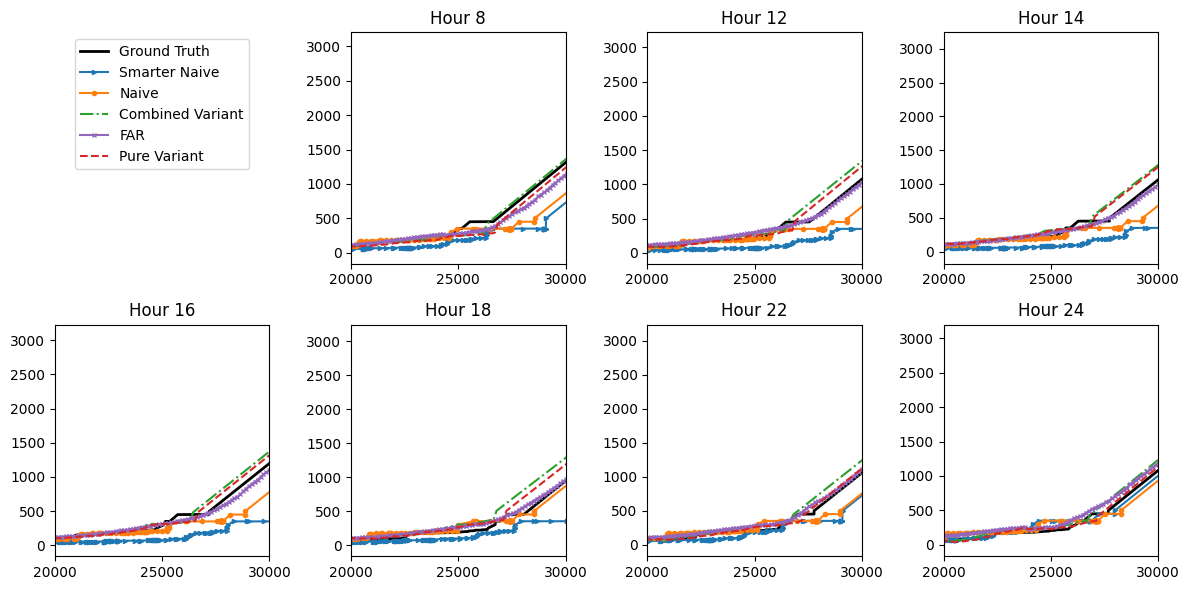

In [32]:
fig, axs = plt.subplots(2, 4, figsize=(12, 6))
hours = [3, 7, 11, 13, 15, 17, 21, 23]
# Flatten the axis array for easy iteration
axs = axs.flatten()
ax_empty = axs[0]
ax_empty.axis('off') 
idx = -10
s = 3
# Iterate over each subplot and plot something
for i, ax in enumerate(axs):
    if i > 0:
        supp = supply_price[np.arange(hours[i],len(supply_price),24)]
        supv = supply_volume[np.arange(hours[i],len(supply_price),24)]
        testv = supv[-160:]
        testp = supp[-160:]

        far_p = pd.read_csv('./FAR_curves/FAR_supply_h_' + str(hours[i]+1) + '.csv')
        far_v = pd.read_csv('./FAR_curves/FAR_supply_grid_h_' + str(hours[i]+1) + '.csv')
    
        
        ax.plot(testv[idx], testp[idx], color = "black", linewidth = "2.0", label = "Ground Truth")
        if vector[len(vector) - 160 + idx - 1] == 0:
            ax.plot(supv[len(supp) - 160 + idx - 1], supp[len(supp) - 160 + idx - 1], "->", label = "Smarter Naive", markersize = s, color = "tab:blue")
        else:
            ax.plot(supv[len(supp) - 160 + idx - 7], supp[len(supp) - 160 + idx - 7], "->", label = "Smarter Naive", markersize = s, color = "tab:blue")
        ax.plot(supv[len(supp) - 160 + idx - 1], supp[len(supp) - 160 + idx - 1], "-o", label = "Naive", markersize = s, color = "tab:orange")
        ax.plot(sup_combined_predv_h_t2[hours[i]][idx],sup_combined_predp_h_t2[hours[i]][idx], "-.", label = "Combined Variant", markersize = s, color = "tab:green")
        ax.plot(far_v.values[:,0],far_p.values[:,idx], "-x", label = "FAR", markersize = s, color = "tab:purple")
        ax.plot(sup_lr_predv_h[hours[i]][idx],sup_lr_predp_h[hours[i]][idx], "--", label = "Pure Variant", markersize = s, color = "tab:red")
        ax.set_title(f'Hour {hours[i]+1}')
        ax.set_xlim([20000,30000])
        ax.set_xticks(np.linspace(20000, 30000, 3, dtype=int))
# Adjust layout to prevent overlap
plt.tight_layout()
handles, labels = ax.get_legend_handles_labels()  # Get legend handles and labels from any non-empty subplot
ax_empty.legend(handles, labels, loc='upper center', ncol=1)  # Add legend to empty subplot
# Show the plot
plt.show()